<a href="https://colab.research.google.com/github/Joammp/ML_Radio_Signal/blob/main/C%C3%B3pia_de_C%C3%B3pia_de_pt_86_1403.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IMPORTS

In [1]:
!pip install scikeras
!pip install tensorflow

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Import numpy for potential future use

from matplotlib import pyplot as plt

import h5py
import json
from numpy import argwhere

from sklearn.model_selection import train_test_split
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import threading # Usaremos threading para garantir a segurança da thread
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import numpy as np
import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [2]:
# Before creating the plot, set the desired font size and name
plt.rcParams['font.size'] = 12  # Change the default font size
plt.rcParams['font.family'] = 'serif'  # Change the default font family (e.g., 'serif', 'sans-serif', 'monospace')

# You can also change these settings for specific text elements if needed.
# For example, to change the title font size:
# plt.title('Plot Title', fontsize=16)


#IMPORT DATASET

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pinxau1000/radioml2018")

print("Path to dataset files:", path)

h5py_path = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
modulation_classes_path = path + '/classes-fixed.json'
# Open the dataset
hdf5_file = h5py.File(h5py_path, 'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']

100%|██████████| 18.0G/18.0G [03:24<00:00, 94.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2


In [4]:


# Load all data from the datasets in the HDF5 file
X = data
Y = modulation_onehot
Z = snr

# Convert one-hot encoded labels to numerical labels
y = np.argmax(Y, axis=1)

#DEFS


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# SEED GLOBAL — garante reprodutibilidade total entre execuções
# Cole esta célula como a PRIMEIRA célula de código do notebook
# ══════════════════════════════════════════════════════════════════════════════

import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Garante operações determinísticas na GPU (pequeno custo de performance)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f"✅ Seeds fixadas: SEED={SEED}")
print(f"   random     : OK")
print(f"   numpy      : OK")
print(f"   torch CPU  : OK")
print(f"   torch CUDA : OK")
print(f"   cudnn det. : OK")

✅ Seeds fixadas: SEED=42
   random     : OK
   numpy      : OK
   torch CPU  : OK
   torch CUDA : OK
   cudnn det. : OK


In [6]:
import torch
import os
from tqdm import tqdm

def train_and_validate(model, train_loader, val_loader, criterion, optimizer,
                       scheduler=None, epochs=10, save_name="best_model"):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # 📁 Diretório padrão do Colab
    SAVE_DIR = "/content"
    os.makedirs(SAVE_DIR, exist_ok=True)

    best_val_acc = 0.0
    best_model_path = None
    epochs_no_improve = 0

    # 🔥 Early stopping baseado no scheduler
    if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        early_stop_patience = scheduler.patience * 2
    else:
        early_stop_patience = 10

    print(f"🛑 Early Stopping patience: {early_stop_patience}")

    for epoch in range(epochs):

        # ── TREINO ──
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        pbar_train = tqdm(train_loader, desc=f"Época {epoch+1}/{epochs} [Treino]")

        for inputs, labels in pbar_train:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # ── VALIDAÇÃO ──
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # ── MÉTRICAS ──
        final_train_loss = train_loss / len(train_loader)
        final_train_acc  = 100. * train_correct / train_total
        final_val_loss   = val_loss / len(val_loader)
        final_val_acc    = 100. * val_correct / val_total

        current_lr = optimizer.param_groups[0]['lr']

        # ── CHECKPOINT MELHOR ──
        if final_val_acc > best_val_acc:
            best_val_acc = final_val_acc
            epochs_no_improve = 0

            # 🧹 remove modelo anterior
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)

            # 🏷 nome com métricas
            filename = (
                f"{save_name}_ep{epoch+1:03d}"
                f"_acc{final_val_acc:.2f}"
                f"_lr{current_lr:.2e}.pth"
            )

            best_model_path = os.path.join(SAVE_DIR, filename)

            torch.save({
                'epoch': epoch + 1,
                'val_acc': final_val_acc,
                'val_loss': final_val_loss,
                'lr': current_lr,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, best_model_path)

            print(f"💾 Novo melhor modelo salvo:")
            print(f"   📁 {best_model_path}")

        else:
            epochs_no_improve += 1

        # ── SCHEDULER ──
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(final_val_acc)  # 🔥 melhor usar ACC
            else:
                scheduler.step()

        # ── LOG ──
        print(f"\nÉpoca {epoch+1}: "
              f"Train Loss: {final_train_loss:.4f} | Train Acc: {final_train_acc:.2f}% | "
              f"Val Loss: {final_val_loss:.4f} | Val Acc: {final_val_acc:.2f}% | "
              f"LR: {current_lr:.2e}")

        # ── EARLY STOP ──
        if epochs_no_improve >= early_stop_patience:
            print(f"\n🛑 Early stopping ativado na época {epoch+1}")
            break

    print(f"\n✅ Melhor Val Acc: {best_val_acc:.2f}%")
    print(f"📁 Modelo salvo em: {best_model_path}")

    return best_model_path

In [7]:


def get_indices_by_snr(target_snrs):
    """
    Separates and returns indices corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        np.ndarray: A sorted numpy array of indices from the original dataset (X, Y, Z, y)
                    where the SNR matches one of the target_snrs.
    """
    # Convert target_snrs to a set for efficient lookup
    target_snrs_set = set(target_snrs)

    # Get the SNR values from the Z array (assuming Z is globally available)
    # Z[:, 0] extracts the SNR column
    all_snr_values = Z[:, 0]

    # Find indices where the SNR value is in the target_snrs_set
    matching_indices = np.where(np.isin(all_snr_values, list(target_snrs_set)))[0]

    return np.sort(matching_indices)

# Example Usage:
# Let's say you want indices for SNR values of -20dB, 0dB, and 10dB
# desired_snrs = [-20, 0, 10]
# selected_snr_indices = get_indices_by_snr(desired_snrs)
#
# print(f"Found {len(selected_snr_indices)} samples with SNR in {desired_snrs}")
#
# # You can then use these indices to access the corresponding data
# # X_filtered_by_snr = X[selected_snr_indices]
# # y_filtered_by_snr = y[selected_snr_indices]
# # Z_filtered_by_snr = Z[selected_snr_indices]

# The previous content of this cell was likely a print statement.
# I'll add a simple print to confirm the function is defined.


In [8]:
def get_samples_by_snr(target_snrs):
    """
    Returns data samples (X, Y, Z, y) corresponding to specified SNR values.

    Args:
        target_snrs (list or np.ndarray): A list or array of SNR values
                                          (e.g., [-20, -10, 0, 10]) to filter by.

    Returns:
        tuple: A tuple containing X_filtered, Y_filtered, Z_filtered, y_filtered
               for the selected SNR values.
    """
    # Use the existing function to get indices for the target SNRs
    selected_indices = get_indices_by_snr(target_snrs)

    # Use these indices to subset the global data arrays
    X_filtered = X[selected_indices]
    Y_filtered = Y[selected_indices]
    Z_filtered = Z[selected_indices]
    y_filtered = y[selected_indices]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, selected_indices

print("Function 'get_samples_by_snr' defined.")

Function 'get_samples_by_snr' defined.


In [9]:
def subset_snr (target_snrs, frac):
    X_snr, Y_snr, Z_snr, y_snn, selected_indices = get_samples_by_snr(target_snrs)

    ind_snr_frac, ind_lixo, Y_snr_frac, Ysnr_lixo = train_test_split(
        selected_indices,
        Y_snr,
        test_size=1-frac,
        random_state=42,
        stratify=Y_snr
    )

    ind_snr_frac = np.sort(ind_snr_frac)
    X_filtered = X[ind_snr_frac]
    Y_filtered = Y[ind_snr_frac]
    Z_filtered = Z[ind_snr_frac]
    y_filtered = y[ind_snr_frac]

    print(f"\nSubset created with {len(selected_indices)} samples for SNR values: {target_snrs}.")
    print(f"Shape of X_filtered: {X_filtered.shape}")
    print(f"Shape of Y_filtered: {Y_filtered.shape}")
    print(f"Shape of Z_filtered: {Z_filtered.shape}")
    print(f"Shape of y_filtered: {y_filtered.shape}")

    return X_filtered, Y_filtered, Z_filtered, y_filtered, ind_snr_frac





In [10]:
def split (indices, lables):
  train_val_indices, test_indices, train_val_lables, test_lables = train_test_split(
        indices,
        lables,
        test_size=0.2,
        random_state=42,
        stratify=lables
    )

  train_indices, val_indices, train_lables, val_lables = train_test_split(
        train_val_indices,
        train_val_lables,
        test_size=0.25,
        random_state=42,
        stratify=train_val_lables
    )

  train_indices_sorted = np.sort(train_indices)
  val_indices_sorted = np.sort(val_indices)
  test_indices_sorted = np.sort(test_indices)

  return train_indices_sorted, val_indices_sorted, test_indices_sorted

#SUBSET HDF5

In [ ]:
import h5py
import numpy as np
import json
import os

# ── Configurações ─────────────────────────────────────────────────────────────

INPUT_FILE   = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'
CLASSES_FILE = path + '/classes-fixed.json'

DESIRED_SNRS = [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
#DESIRED_SNRS = [30]
# DESIRED_SNRS = [30]

BATCH_SIZE   = 2048
NUM_GROUPS   = 6

GROUP_MAP = {
    "OOK":       0, "4ASK":      0, "8ASK":      0,
    "BPSK":      1, "QPSK":      1, "8PSK":      1,
    "16PSK":     1, "32PSK":     1, "GMSK":      1, "OQPSK":     1,
    "16APSK":    2, "32APSK":    2, "64APSK":    2, "128APSK":   2,
    "16QAM":     3, "32QAM":     3, "64QAM":     3, "128QAM":    3, "256QAM":    3,
    "AM-SSB-WC": 4, "AM-SSB-SC": 4, "AM-DSB-WC": 4, "AM-DSB-SC": 4,
    "FM":        5,
}
GROUP_NAMES = {0: "ASK", 1: "PSK", 2: "APSK", 3: "QAM", 4: "AM", 5: "FM"}

for _dir in ['/kaggle/working', '/tmp', '/root']:
    if os.path.exists(_dir) and os.access(_dir, os.W_OK):
        snr_tag     = '_'.join(str(s) for s in DESIRED_SNRS)
        OUTPUT_FILE = os.path.join(_dir, f'subset_snr_{snr_tag}.hdf5')
        break

print(f"Input  : {INPUT_FILE}")
print(f"Output : {OUTPUT_FILE}")
print(f"SNRs   : {DESIRED_SNRS}\n")

if os.path.exists(OUTPUT_FILE):
    try:
        os.remove(OUTPUT_FILE)
        print(f"Arquivo anterior removido: {OUTPUT_FILE}\n")
    except OSError as e:
        print(f"Erro ao remover {OUTPUT_FILE}: {e}")

# ── Lookup de grupos ──────────────────────────────────────────────────────────

modulation_classes = json.load(open(CLASSES_FILE, 'r'))
lookup = np.array([GROUP_MAP[modulation_classes[i]]
                   for i in range(len(modulation_classes))], dtype=np.int64)



# ── Passo 1: Identifica índices com os SNRs desejados ─────────────────────────

print("Passo 1/2 — Identificando índices dos SNRs selecionados...")

original_indices = []   # índices do dataset ORIGINAL — usados apenas para leitura
snr_set          = set(DESIRED_SNRS)

with h5py.File(INPUT_FILE, 'r') as src:
    N         = src['X'].shape[0]
    Z         = src['Z']
    n_batches = int(np.ceil(N / BATCH_SIZE))

    for i in range(n_batches):
        start, end = i * BATCH_SIZE, min((i + 1) * BATCH_SIZE, N)
        z_batch    = Z[start:end, 0]
        mask       = np.isin(z_batch, list(snr_set))
        global_idx = np.where(mask)[0] + start
        original_indices.extend(global_idx.tolist())

        if (i + 1) % 20 == 0 or i == n_batches - 1:
            print(f"  Batch {i+1:>4}/{n_batches}  | selecionados até agora: {len(original_indices)}")

original_indices = np.array(original_indices, dtype=np.int64)
M = len(original_indices)
print(f"\nTotal selecionado: {M} amostras de {N} ({100*M/N:.1f}%)\n")

# ── Passo 2: Cria novo arquivo com índices próprios a partir de 0 ─────────────

print("Passo 2/2 — Criando novo dataset com índices a partir de 0...")

with h5py.File(INPUT_FILE, 'r') as src:
    x_shape = src['X'].shape[1:]
    x_dtype = src['X'].dtype
    y_shape = src['Y'].shape[1:]
    y_dtype = src['Y'].dtype
    z_shape = src['Z'].shape[1:]
    z_dtype = src['Z'].dtype

    chunk = (min(BATCH_SIZE, M),)

    with h5py.File(OUTPUT_FILE, 'w') as out:

        # Grava metadado dos SNRs para rastreabilidade (não afeta indexação)
        out.attrs['snrs']            = DESIRED_SNRS
        out.attrs['source_file']     = INPUT_FILE
        out.attrs['total_samples']   = M




        ds_X  = out.create_dataset('X',         shape=(M,) + x_shape,
                                   dtype=x_dtype,    chunks=chunk + x_shape)

        ds_Y  = out.create_dataset('Y',         shape=(M,) + y_shape,
                                   dtype=y_dtype,    chunks=chunk + y_shape)

        ds_Z  = out.create_dataset('Z',         shape=(M,) + z_shape,
                                   dtype=z_dtype,    chunks=chunk + z_shape)

        ds_YG = out.create_dataset('Y_grouped', shape=(M, NUM_GROUPS),
                                   dtype=np.float32, chunks=chunk + (NUM_GROUPS,))

        n_batches = int(np.ceil(M / BATCH_SIZE))

        for i in range(n_batches):
            # new_start/new_end → índices do NOVO arquivo (começam em 0)
            new_start, new_end = i * BATCH_SIZE, min((i + 1) * BATCH_SIZE, M)

            # batch_idx → índices do arquivo ORIGINAL (apenas para leitura)
            batch_idx = original_indices[new_start:new_end].tolist()

            ds_X[new_start:new_end]  = src['X'][batch_idx]
            ds_Y[new_start:new_end]  = src['Y'][batch_idx]
            ds_Z[new_start:new_end]  = src['Z'][batch_idx]

            # Gera Y_grouped inline
            y_idx    = np.argmax(src['Y'][batch_idx], axis=1)
            y_group  = lookup[y_idx]
            YG_batch = np.zeros((new_end - new_start, NUM_GROUPS), dtype=np.float32)
            YG_batch[np.arange(new_end - new_start), y_group] = 1.0
            ds_YG[new_start:new_end] = YG_batch

            if (i + 1) % 10 == 0 or i == n_batches - 1:
                print(f"  Batch {i+1:>4}/{n_batches}  "
                      f"novo [{new_start:>8}:{new_end:>8}]  "
                      f"original [{batch_idx[0]:>8}:{batch_idx[-1]:>8}]")

# ── Deleta original_indices para não contaminar uso posterior ─────────────────

del original_indices
print("\noriginal_indices deletado do escopo — novo dataset usa apenas índices 0..M-1")

# ── Verificação ───────────────────────────────────────────────────────────────

print("\nVerificando arquivo gerado...")

with h5py.File(OUTPUT_FILE, 'r') as f:
    M_check = f['X'].shape[0]

    print(f"\n  Datasets : {list(f.keys())}")
    print(f"  Atributos: snrs={list(f.attrs['snrs'])}  "
          f"total_samples={f.attrs['total_samples']}")
    print(f"  X         : {f['X'].shape}  dtype={f['X'].dtype}")
    print(f"  Y         : {f['Y'].shape}  dtype={f['Y'].dtype}")
    print(f"  Z         : {f['Z'].shape}  dtype={f['Z'].dtype}")
    print(f"  Y_grouped : {f['Y_grouped'].shape}  dtype={f['Y_grouped'].dtype}")

    # Confirma que os índices do novo arquivo vão de 0 a M-1
    assert M_check == M, "Número de amostras diverge!"
    print(f"\n  Índices do novo dataset : 0 → {M_check - 1}  ✓")

    snrs_found = np.unique(f['Z'][:, 0])
    assert set(snrs_found.tolist()) == snr_set, "SNRs inesperados!"
    print(f"  SNRs presentes          : {snrs_found.tolist()}  ✓")

    yg = f['Y_grouped'][:]
    assert np.all(yg.sum(axis=1) == 1.0), "One-hot inválido em Y_grouped!"
    print(f"  Verificação one-hot     : OK  ✓")

print(f"\nArquivo salvo em: {OUTPUT_FILE}")

Input  : /root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5
Output : /tmp/subset_snr_-20_-18_-16_-14_-12_-10_-8_-6_-4_-2_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5
SNRs   : [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]

Arquivo anterior removido: /tmp/subset_snr_-20_-18_-16_-14_-12_-10_-8_-6_-4_-2_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5

Passo 1/2 — Identificando índices dos SNRs selecionados...
  Batch   20/1248  | selecionados até agora: 40960
  Batch   40/1248  | selecionados até agora: 81920
  Batch   60/1248  | selecionados até agora: 122880
  Batch   80/1248  | selecionados até agora: 163840
  Batch  100/1248  | selecionados até agora: 204800
  Batch  120/1248  | selecionados até agora: 245760
  Batch  140/1248  | selecionados até agora: 286720
  Batch  160/1248  | selecionados até agora: 327680
  Batch  180/1248  | selecionados até agora: 368640
  Batch  200/1248  

KeyboardInterrupt: 

In [ ]:
OUTPUT_FILE

In [ ]:
h5py_path = OUTPUT_FILE


hdf5_file = h5py.File(h5py_path, 'r')
# Load the modulation classes. You can also copy and paste the content of classes-fixed.txt.
modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Read the HDF5 groups
data = hdf5_file['X']
modulation_onehot = hdf5_file['Y_grouped']
# modulation_onehot = hdf5_file['Y']
snr = hdf5_file['Z']


# Load all data from the datasets in the HDF5 file
X = data
Y = modulation_onehot
Z = snr

# Convert one-hot encoded labels to numerical labels
y = np.argmax(Y, axis=1)

In [ ]:
num_samples = X.shape[0]
indices = np.arange(num_samples) #selected_indices_sorted
lables = np.column_stack((y, Z))

train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

#.

In [14]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
from torch.utils.data import Dataset
class H5PyDataset(Dataset):
    def __init__(self, h5_filepath, data_X_name, data_Y_name, data_Z_name, indices, formats):
        self.h5_filepath = h5_filepath
        self.data_X_name = data_X_name
        self.data_Y_name = data_Y_name
        self.indices = np.array(indices)
        self.formats = formats
        self.file = None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Abre o arquivo apenas uma vez por worker
        if self.file is None:
            self.file = h5py.File(self.h5_filepath, 'r')
            self.X_data = self.file[self.data_X_name]
            self.Y_data = self.file[self.data_Y_name]

        # Pega o índice real baseado na sua lista de sorteados
        real_idx = self.indices[idx]

        # Busca UMA amostra (1024, 2)
        x = self.X_data[real_idx, :]
        y = self.Y_data[real_idx]

        # Normalização Individual
        # mean = x.mean()
        # std = x.std()
        # x = (x - mean) / (std + 1e-8)

        # Trata o Label
        if self.formats == 0:
            # Se y for um vetor (One-Hot), pega o índice da classe
            if hasattr(y, "__len__"):
                y = np.argmax(y)

        # Conversão para Tensor
        x_tensor = torch.from_numpy(x).float() # [1024, 2]
        x_tensor = x_tensor.permute(1, 0)      # [2, 1024] (Canais primeiro)
        y_tensor = torch.tensor(y).long()      # Valor escalar

        return x_tensor, y_tensor

In [16]:
num_samples = X.shape[0]
indices = np.arange(num_samples) #selected_indices_sorted
lables = np.column_stack((y, Z))

train_indices_sorted, val_indices_sorted, test_indices_sorted = split(indices, lables)

In [17]:
from torch.utils.data import DataLoader, BatchSampler, RandomSampler, SequentialSampler, random_split

# 1. Dataset (Certifique-se que o __getitem__ aceita a lista de índices como discutimos)
# Dataset de Treino
train_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=train_indices_sorted,  # Seus índices de treino
    formats=0
)

# Dataset de Validação
val_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=val_indices_sorted,    # Seus índices de validação
    formats=0
)

test_dataset = H5PyDataset(
    h5_filepath=h5py_path,
    data_X_name='X',
    data_Y_name='Y',
    data_Z_name='Z',
    indices=test_indices_sorted,    # Seus índices de validação
    formats=0
)

batch_size = 64

# Remova o BatchSampler e o collate_fn.
# Use shuffle=True para o treino e shuffle=False para validação.
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,          # Isso substitui o RandomSampler
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,         # Isso substitui o SequentialSampler
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,         # Isso substitui o SequentialSampler
    drop_last=False
)

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS COM SEED CONTROLADA
# ══════════════════════════════════════════════════════════════════════════════

import torch
from torch.utils.data import DataLoader

SEED       = 42
batch_size = 64

# Gerador dedicado para o DataLoader — controla o shuffle entre épocas
g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    """Garante seeds determinísticas nos workers do DataLoader."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    persistent_workers=False,
    generator=g,               # controla a ordem do shuffle
    worker_init_fn=seed_worker # controla seeds dos workers (se num_workers>0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    persistent_workers=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    persistent_workers=False
)

In [19]:
import torch.nn as nn
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=11, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=5, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(512, 1024, kernel_size=3, padding=1),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.MaxPool1d(2)


        )

        # Técnica para detectar o tamanho do flatten automaticamente:
        self.flatten = nn.Flatten()
        with torch.no_grad():
            # Passamos um dado "dummy" de teste para ver o que sai das convs
            dummy_input = torch.zeros(1, 2, 1024)
            dummy_output = self.features(dummy_input)
            self.n_flatten = dummy_output.view(1, -1).size(1)

        print(f"Tamanho detectado para o Flatten: {self.n_flatten}")

        self.classifier = nn.Sequential(
            nn.Linear(self.n_flatten, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

In [20]:
# -*- coding: utf-8 -*-
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║         CÉLULA UNIFICADA — SELECIONAR → BUSCAR → CRIAR → TREINAR         ║
# ║                                                                          ║
# ║  Pré-requisitos (células anteriores já executadas):                      ║
# ║    • kagglehub.dataset_download() → variável  path                       ║
# ║    • modulation_classes_path definido                                    ║
# ║    • Classes H5PyDataset e CNN definidas                                 ║
# ║    • Funções split() / split_indices() e train_and_validate() definidas  ║
# ║    • Drive montado:                                                      ║
# ║        from google.colab import drive                                    ║
# ║        drive.mount('/content/drive', force_remount=True)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import os, json, shutil, random
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# ══════════════════════════════════════════════════════════════════════════════
# ▶▶  CONFIGURAÇÃO — altere apenas este bloco  ◀◀
# ══════════════════════════════════════════════════════════════════════════════

MODELO_ALVO = "GROUP"
# Opções: "GROUP" | "ASK" | "PSK" | "APSK" | "QAM" | "AM" | "FM"

DESIRED_SNRS = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
   # todos os SNRs disponíveis
# Para treinar em SNR alto apenas: list(range(0, 32, 2))

EPOCHS       = 120
BATCH_SIZE   = 64
LR           = 5e-4
SEED         = 42

DRIVE_BASE   = "/content/drive/MyDrive/radioml_sessions"
LOCAL_DIR    = "/content"          # onde o HDF5 fica durante a sessão
HDF5_BUILD_BATCH = 2048            # batch de I/O para montar o HDF5

# ══════════════════════════════════════════════════════════════════════════════
# MAPA DE GRUPOS (igual ao resto do notebook)
# ══════════════════════════════════════════════════════════════════════════════

GROUP_MAP = {
    "OOK":       0, "4ASK":      0, "8ASK":      0,
    "BPSK":      1, "QPSK":      1, "8PSK":      1,
    "16PSK":     1, "32PSK":     1, "GMSK":      1, "OQPSK":     1,
    "16APSK":    2, "32APSK":    2, "64APSK":    2, "128APSK":   2,
    "16QAM":     3, "32QAM":     3, "64QAM":     3, "128QAM":    3, "256QAM":    3,
    "AM-SSB-WC": 4, "AM-SSB-SC": 4, "AM-DSB-WC": 4, "AM-DSB-SC": 4,
    "FM":        5,
}
GROUP_NAMES  = {0: "ASK", 1: "PSK", 2: "APSK", 3: "QAM", 4: "AM", 5: "FM"}
ALL_MODELS   = ["GROUP", "ASK", "PSK", "APSK", "QAM", "AM", "FM"]

INPUT_FILE   = path + "/GOLD_XYZ_OSC.0001_1024.hdf5"
CLASSES_FILE = modulation_classes_path

assert MODELO_ALVO in ALL_MODELS, f"MODELO_ALVO inválido: {MODELO_ALVO}"

# ══════════════════════════════════════════════════════════════════════════════
# SEEDS
# ══════════════════════════════════════════════════════════════════════════════

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _seed_worker(worker_id):
    s = torch.initial_seed() % (2**32)
    np.random.seed(s); random.seed(s)

# ══════════════════════════════════════════════════════════════════════════════
# DERIVAÇÕES — group_indices, num_classes, global_to_local, nomes de arquivo
# ══════════════════════════════════════════════════════════════════════════════

mod_classes = json.load(open(CLASSES_FILE))

if MODELO_ALVO == "GROUP":
    # Classifica os 24 sinais em 6 grupos  →  label = GROUP_MAP[mod]
    group_indices   = np.arange(len(mod_classes), dtype=np.int64)
    num_classes     = 6
    global_to_local = {int(g): GROUP_MAP[mod_classes[g]] for g in group_indices}
    h5_label_key    = "Y_grouped"    # one-hot de 6 classes
    _label_note     = "6 grupos (ASK/PSK/APSK/QAM/AM/FM)"
else:
    # Classifica dentro do grupo escolhido
    group_indices = np.array(
        sorted([i for i, m in enumerate(mod_classes)
                if GROUP_NAMES[GROUP_MAP[m]] == MODELO_ALVO]),
        dtype=np.int64
    )
    num_classes     = len(group_indices)
    global_to_local = {int(g): l for l, g in enumerate(group_indices)}
    h5_label_key    = "Y"
    _label_note     = f"{num_classes} classes intra-grupo {MODELO_ALVO}"

snr_tag   = "_".join(str(s) for s in DESIRED_SNRS)
h5_name   = (f"GROUP_subset_snr_{snr_tag}.hdf5" if MODELO_ALVO == "GROUP"
             else f"{MODELO_ALVO}_subset_snr_{snr_tag}.hdf5")
h5_local  = os.path.join(LOCAL_DIR,  h5_name)
h5_drive  = os.path.join(DRIVE_BASE, MODELO_ALVO, "subset.hdf5")
ckpt_drive= os.path.join(DRIVE_BASE, MODELO_ALVO, "checkpoint.pth")
meta_drive= os.path.join(DRIVE_BASE, MODELO_ALVO, "meta.json")
idx_drive = lambda name: os.path.join(DRIVE_BASE, MODELO_ALVO, f"{name}.npy")

sep = "═" * 65
print(sep)
print(f"  Modelo  : {MODELO_ALVO}  ({_label_note})")
print(f"  SNRs    : {DESIRED_SNRS}")
print(f"  Device  : {device}")
print(sep)

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 1 — VERIFICAR DRIVE
# ══════════════════════════════════════════════════════════════════════════════

assert os.path.exists("/content/drive/MyDrive"), (
    "\n\n❌ Google Drive não montado!\n"
    "   Execute antes:\n"
    "       from google.colab import drive\n"
    "       drive.mount('/content/drive', force_remount=True)\n"
)

has_h5   = os.path.exists(h5_drive)
has_ckpt = os.path.exists(ckpt_drive)
has_idx  = all(os.path.exists(idx_drive(n))
               for n in ("train_indices", "val_indices", "test_indices"))

print(f"\n📂 Drive  →  {os.path.join(DRIVE_BASE, MODELO_ALVO)}")
print(f"   HDF5        : {'✅ encontrado' if has_h5   else '❌ não existe — será criado'}")
print(f"   Checkpoint  : {'✅ encontrado' if has_ckpt else '❌ não existe — treino do zero'}")
print(f"   Índices     : {'✅ encontrado' if has_idx  else '❌ não existe — será gerado'}")

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 2 — OBTER HDF5 LOCAL (do Drive ou criar do zero)
# ══════════════════════════════════════════════════════════════════════════════

def _build_hdf5(input_file, output_file, target_snrs,
                group_indices, global_to_local, num_classes,
                modelo_id, batch_size=2048):
    """Filtra INPUT_FILE por SNR (e grupo se intra-grupo) e grava output_file."""
    snr_set = set(target_snrs)
    if os.path.exists(output_file):
        os.remove(output_file)

    print(f"\n  🔨 Construindo HDF5 para '{modelo_id}'...")

    original_indices = []
    with h5py.File(input_file, 'r') as src:
        N     = src['X'].shape[0]
        Z_ds  = src['Z']
        Y_ds  = src['Y']
        n_b   = int(np.ceil(N / batch_size))

        for i in range(n_b):
            s, e     = i * batch_size, min((i + 1) * batch_size, N)
            z_batch  = Z_ds[s:e, 0]
            y_batch  = np.argmax(Y_ds[s:e], axis=1)

            if modelo_id == "GROUP":
                mask = np.isin(z_batch, list(snr_set))
            else:
                mask = (np.isin(z_batch, list(snr_set)) &
                        np.isin(y_batch, group_indices))

            original_indices.extend((np.where(mask)[0] + s).tolist())
            if (i + 1) % 50 == 0 or i == n_b - 1:
                print(f"    Batch {i+1:>4}/{n_b}  |  amostras: {len(original_indices)}")

    original_indices = np.array(original_indices, dtype=np.int64)
    M = len(original_indices)
    if M == 0:
        raise ValueError("Nenhuma amostra encontrada com os filtros escolhidos.")

    NUM_GROUPS = 6
    lookup = np.array([GROUP_MAP[mod_classes[i]]
                       for i in range(len(mod_classes))], dtype=np.int64)

    with h5py.File(input_file, 'r') as src:
        x_shape = src['X'].shape[1:]
        z_shape = src['Z'].shape[1:]

        with h5py.File(output_file, 'w') as out:
            # Metadados para reconstrução futura
            out.attrs['snrs']          = target_snrs
            out.attrs['modelo_id']     = modelo_id
            out.attrs['num_classes']   = num_classes
            out.attrs['group_indices'] = group_indices.tolist()
            out.attrs['total_samples'] = M
            out.attrs['seed']          = SEED

            ds_X  = out.create_dataset('X', shape=(M,)+x_shape, dtype=src['X'].dtype)
            ds_Z  = out.create_dataset('Z', shape=(M,)+z_shape, dtype=src['Z'].dtype)

            if modelo_id == "GROUP":
                # Y_grouped: one-hot de 6 grupos
                ds_Y = out.create_dataset('Y_grouped',
                                          shape=(M, NUM_GROUPS), dtype=np.float32)
            else:
                # Y: one-hot local (num_classes do grupo)
                ds_Y = out.create_dataset('Y',
                                          shape=(M, num_classes), dtype=np.int32)

            n_b = int(np.ceil(M / batch_size))
            for i in range(n_b):
                s, e = i * batch_size, min((i + 1) * batch_size, M)
                idx  = original_indices[s:e]

                ds_X[s:e] = src['X'][idx]
                ds_Z[s:e] = src['Z'][idx]

                y_global = np.argmax(src['Y'][idx], axis=1)

                if modelo_id == "GROUP":
                    y_group = lookup[y_global]
                    yg = np.zeros((e - s, NUM_GROUPS), dtype=np.float32)
                    yg[np.arange(e - s), y_group] = 1.0
                    ds_Y[s:e] = yg
                else:
                    y_local = np.array([global_to_local[int(g)] for g in y_global])
                    yo = np.zeros((e - s, num_classes), dtype=np.int32)
                    yo[np.arange(e - s), y_local] = 1
                    ds_Y[s:e] = yo

                if (i + 1) % 20 == 0 or i == n_b - 1:
                    print(f"    Escrevendo batch {i+1:>4}/{n_b}")

    print(f"  ✅ HDF5 criado: {output_file}  ({M} amostras)")
    return output_file


if has_h5:
    # ── Copia Drive → local (se ainda não copiado) ────────────────────────
    if not os.path.exists(h5_local):
        print(f"\n📦 Copiando HDF5 do Drive → {h5_local}  (pode demorar)…")
        shutil.copy(h5_drive, h5_local)
        print("  ✅ Cópia concluída.")
    else:
        print(f"\n📦 HDF5 já disponível localmente: {h5_local}")
else:
    # ── Cria do zero ─────────────────────────────────────────────────────
    _build_hdf5(INPUT_FILE, h5_local, DESIRED_SNRS,
                group_indices, global_to_local, num_classes, MODELO_ALVO,
                batch_size=HDF5_BUILD_BATCH)

    # Guarda no Drive para próximas sessões
    print(f"\n  💾 Salvando HDF5 no Drive…")
    os.makedirs(os.path.join(DRIVE_BASE, MODELO_ALVO), exist_ok=True)
    shutil.copy(h5_local, h5_drive)
    print(f"  ✅ {h5_drive}")

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 3 — ÍNDICES TRAIN / VAL / TEST  (carrega ou gera — sem data leakage)
# ══════════════════════════════════════════════════════════════════════════════

def _split_deterministic(h5_path, label_key, seed=42):
    """Gera split 60/20/20 estratificado apenas pelo label (sem SNR no stratify)."""
    with h5py.File(h5_path, 'r') as f:
        Y_all = f[label_key][:]
    y_all   = np.argmax(Y_all, axis=1)
    indices = np.arange(len(y_all))

    tv_idx, te_idx, tv_lbl, _ = train_test_split(
        indices, y_all, test_size=0.20, random_state=seed, stratify=y_all
    )
    tr_idx, va_idx, _, _ = train_test_split(
        tv_idx, tv_lbl, test_size=0.25, random_state=seed, stratify=tv_lbl
    )
    return np.sort(tr_idx), np.sort(va_idx), np.sort(te_idx)


if has_idx:
    print("\n📐 Carregando índices do Drive…")
    train_indices = np.load(idx_drive("train_indices"))
    val_indices   = np.load(idx_drive("val_indices"))
    test_indices  = np.load(idx_drive("test_indices"))
    print(f"   train={len(train_indices)} | val={len(val_indices)} | test={len(test_indices)}")
else:
    print("\n📐 Gerando índices (split determinístico)…")
    train_indices, val_indices, test_indices = _split_deterministic(
        h5_local, h5_label_key, seed=SEED
    )
    print(f"   train={len(train_indices)} | val={len(val_indices)} | test={len(test_indices)}")

    # Persiste no Drive
    os.makedirs(os.path.join(DRIVE_BASE, MODELO_ALVO), exist_ok=True)
    np.save(idx_drive("train_indices"), train_indices)
    np.save(idx_drive("val_indices"),   val_indices)
    np.save(idx_drive("test_indices"),  test_indices)
    print("   ✅ Índices salvos no Drive.")

# Verificação anti-leakage
tr_s, va_s, te_s = set(train_indices), set(val_indices), set(test_indices)
assert not (tr_s & va_s), "❌ Sobreposição treino/val!"
assert not (tr_s & te_s), "❌ Sobreposição treino/test!"
assert not (va_s & te_s), "❌ Sobreposição val/test!"
print("   ✅ Sem sobreposição entre splits (anti-leakage OK)")

# Variáveis globais compatíveis com o restante do notebook
train_indices_sorted = train_indices
val_indices_sorted   = val_indices
test_indices_sorted  = test_indices
h5py_path            = h5_local

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 4 — DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════

g = torch.Generator(); g.manual_seed(SEED)

train_dataset = H5PyDataset(
    h5_filepath=h5_local,
    data_X_name='X',
    data_Y_name=h5_label_key,
    data_Z_name='Z',
    indices=train_indices,
    formats=0
)

val_dataset = H5PyDataset(
    h5_filepath=h5_local,
    data_X_name='X',
    data_Y_name=h5_label_key,
    data_Z_name='Z',
    indices=val_indices,
    formats=0
)

test_dataset = H5PyDataset(
    h5_filepath=h5_local,
    data_X_name='X',
    data_Y_name=h5_label_key,
    data_Z_name='Z',
    indices=test_indices,
    formats=0
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=False, num_workers=0,
                          generator=g, worker_init_fn=_seed_worker)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          drop_last=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          drop_last=False, num_workers=0)

print(f"\n📊 DataLoaders prontos:")
print(f"   Treino     : {len(train_dataset):>8} amostras")
print(f"   Validação  : {len(val_dataset):>8} amostras")
print(f"   Teste      : {len(test_dataset):>8} amostras")

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 5 — INSTANCIAR MODELO  (carrega checkpoint se existir)
# ══════════════════════════════════════════════════════════════════════════════

model     = CNN(num_classes=num_classes).to(device)
epoch_ini = 0                    # época de onde o treino começa
best_acc  = 0.0                  # melhor val_acc conhecida até agora

if has_ckpt:
    print(f"\n🔄 Carregando checkpoint do Drive…")
    ckpt = torch.load(ckpt_drive, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    epoch_ini = ckpt.get("epoch", 0)
    best_acc  = ckpt.get("val_acc", 0.0)
    print(f"   Retomando da época {epoch_ini}  |  melhor val_acc = {best_acc:.2f}%")
else:
    print(f"\n⚙️  Nenhum checkpoint encontrado — treinando do zero.")

print(f"   CNN instanciada com {num_classes} classes | Flatten: {model.n_flatten}")

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 6 — OTIMIZADOR E SCHEDULER
# ══════════════════════════════════════════════════════════════════════════════

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-8
)

if has_ckpt:
    # Tenta restaurar estado do otimizador (opcional — ignora se não existir)
    try:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])
        print("   ✅ Estado do otimizador restaurado.")
    except Exception:
        print("   ⚠️  Estado do otimizador não restaurado — usando valores padrão.")

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 7 — TREINAR
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{sep}")
print(f"  🚀 Iniciando treino — modelo '{MODELO_ALVO}'  |  épocas: {EPOCHS}  |  LR: {LR}")
print(sep)

best_model_path = train_and_validate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler  = scheduler,
    epochs     = EPOCHS,
    save_name  = f"cnn_{MODELO_ALVO}",
)

# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 8 — SALVAR NO DRIVE
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{sep}")
print("  💾 Salvando sessão no Drive…")
print(sep)

save_dir = os.path.join(DRIVE_BASE, MODELO_ALVO)
os.makedirs(save_dir, exist_ok=True)

# Checkpoint
shutil.copy(best_model_path, ckpt_drive)
print(f"  ✅ Checkpoint  → {ckpt_drive}")

# Índices (já salvos na etapa 3 se eram novos; re-salva para garantir)
np.save(idx_drive("train_indices"), train_indices_sorted)
np.save(idx_drive("val_indices"),   val_indices_sorted)
np.save(idx_drive("test_indices"),  test_indices_sorted)
print(f"  ✅ Índices     → {save_dir}/[train|val|test]_indices.npy")

# HDF5 (já copiado na etapa 2; só avisa)
print(f"  ✅ HDF5        → {h5_drive}  (já persistido)")

# meta.json
with h5py.File(best_model_path if best_model_path.endswith(".hdf5") else h5_local, 'r') as _f:
    h5_attrs = {k: (list(v) if hasattr(v, '__iter__') else int(v))
                for k, v in _f.attrs.items()}

ckpt_final = torch.load(best_model_path, map_location="cpu")
meta = {
    "modelo_id":    MODELO_ALVO,
    "seed":         SEED,
    "desired_snrs": DESIRED_SNRS,
    "num_classes":  num_classes,
    "group_indices": group_indices.tolist(),
    "train_size":   int(len(train_indices_sorted)),
    "val_size":     int(len(val_indices_sorted)),
    "test_size":    int(len(test_indices_sorted)),
    "best_epoch":   int(ckpt_final.get("epoch", -1)),
    "best_val_acc": float(ckpt_final.get("val_acc", -1)),
    "h5_attrs":     h5_attrs,
}
with open(meta_drive, "w") as fp:
    json.dump(meta, fp, indent=2, ensure_ascii=False)
print(f"  ✅ meta.json   → {meta_drive}")

print(f"\n{'═'*65}")
print(f"  ✅ Sessão '{MODELO_ALVO}' completa e persistida no Drive.")
print(f"  📁 {save_dir}")
print(f"{'═'*65}")

═════════════════════════════════════════════════════════════════
  Modelo  : GROUP  (6 grupos (ASK/PSK/APSK/QAM/AM/FM))
  SNRs    : [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
  Device  : cuda
═════════════════════════════════════════════════════════════════

📂 Drive  →  /content/drive/MyDrive/radioml_sessions/GROUP
   HDF5        : ❌ não existe — será criado
   Checkpoint  : ✅ encontrado
   Índices     : ✅ encontrado

  🔨 Construindo HDF5 para 'GROUP'...
    Batch   50/1248  |  amostras: 61440
    Batch  100/1248  |  amostras: 122880
    Batch  150/1248  |  amostras: 184320
    Batch  200/1248  |  amostras: 245760
    Batch  250/1248  |  amostras: 307200
    Batch  300/1248  |  amostras: 368640
    Batch  350/1248  |  amostras: 430080
    Batch  400/1248  |  amostras: 491520
    Batch  450/1248  |  amostras: 552960
    Batch  500/1248  |  amostras: 614400
    Batch  550/1248  |  amostras: 675840
    Batch  600/1248  |  amostras: 737280
    Batch  650/1248  |  amostras

KeyboardInterrupt: 

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 7 — TREINAR
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{sep}")
print(f"  🚀 Iniciando treino — modelo '{MODELO_ALVO}'  |  épocas: {EPOCHS}  |  LR: {LR}")
print(sep)

best_model_path = train_and_validate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler  = scheduler,
    epochs     = EPOCHS,
    save_name  = f"cnn_{MODELO_ALVO}",
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ETAPA 8 — SALVAR NO DRIVE
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{sep}")
print("  💾 Salvando sessão no Drive…")
print(sep)

save_dir = os.path.join(DRIVE_BASE, MODELO_ALVO)
os.makedirs(save_dir, exist_ok=True)

# Checkpoint
shutil.copy(best_model_path, ckpt_drive)
print(f"  ✅ Checkpoint  → {ckpt_drive}")

# Índices (já salvos na etapa 3 se eram novos; re-salva para garantir)
np.save(idx_drive("train_indices"), train_indices_sorted)
np.save(idx_drive("val_indices"),   val_indices_sorted)
np.save(idx_drive("test_indices"),  test_indices_sorted)
print(f"  ✅ Índices     → {save_dir}/[train|val|test]_indices.npy")

# HDF5 (já copiado na etapa 2; só avisa)
print(f"  ✅ HDF5        → {h5_drive}  (já persistido)")

# meta.json
with h5py.File(best_model_path if best_model_path.endswith(".hdf5") else h5_local, 'r') as _f:
    h5_attrs = {k: (list(v) if hasattr(v, '__iter__') else int(v))
                for k, v in _f.attrs.items()}

ckpt_final = torch.load(best_model_path, map_location="cpu")
meta = {
    "modelo_id":    MODELO_ALVO,
    "seed":         SEED,
    "desired_snrs": DESIRED_SNRS,
    "num_classes":  num_classes,
    "group_indices": group_indices.tolist(),
    "train_size":   int(len(train_indices_sorted)),
    "val_size":     int(len(val_indices_sorted)),
    "test_size":    int(len(test_indices_sorted)),
    "best_epoch":   int(ckpt_final.get("epoch", -1)),
    "best_val_acc": float(ckpt_final.get("val_acc", -1)),
    "h5_attrs":     h5_attrs,
}
with open(meta_drive, "w") as fp:
    json.dump(meta, fp, indent=2, ensure_ascii=False)
print(f"  ✅ meta.json   → {meta_drive}")

print(f"\n{'═'*65}")
print(f"  ✅ Sessão '{MODELO_ALVO}' completa e persistida no Drive.")
print(f"  📁 {save_dir}")
print(f"{'═'*65}")

In [ ]:
print(H5PyDataset.__init__.__code__.co_varnames)

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   SALVAR CHECKPOINT LOCAL (/content) → GOOGLE DRIVE         ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import shutil

# ──────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────

MODELO_ALVO = "GROUP"

# arquivo atual no Colab
ckpt_local = "/content/cnn_GROUP_ep007_acc90.86_lr1.00e-03.pth"

# destino esperado pelo seu pipeline
DRIVE_BASE = "/content/drive/MyDrive/radioml_sessions"
ckpt_drive = os.path.join(DRIVE_BASE, MODELO_ALVO, "checkpoint.pth")

# ──────────────────────────────────────────────────────────────
# GARANTIR QUE O DRIVE ESTÁ MONTADO
# ──────────────────────────────────────────────────────────────

assert os.path.exists("/content/drive/MyDrive"), \
    "❌ Drive não montado! Rode: drive.mount('/content/drive')"

# ──────────────────────────────────────────────────────────────
# GARANTIR QUE O ARQUIVO EXISTE
# ──────────────────────────────────────────────────────────────

assert os.path.exists(ckpt_local), \
    f"❌ Arquivo não encontrado: {ckpt_local}"

# ──────────────────────────────────────────────────────────────
# CRIAR DIRETÓRIO NO DRIVE (se necessário)
# ──────────────────────────────────────────────────────────────

os.makedirs(os.path.dirname(ckpt_drive), exist_ok=True)

# ──────────────────────────────────────────────────────────────
# COPIAR E RENOMEAR
# ──────────────────────────────────────────────────────────────

shutil.copy(ckpt_local, ckpt_drive)

print("✅ Checkpoint salvo no Drive!")
print(f"📂 Origem : {ckpt_local}")
print(f"📂 Destino: {ckpt_drive}")

# ──────────────────────────────────────────────────────────────
# VERIFICAÇÃO FINAL
# ──────────────────────────────────────────────────────────────

print("\n🔍 Verificação:")
print("Existe no destino?", os.path.exists(ckpt_drive))

In [ ]:
import os

path = "/content/drive/MyDrive/radioml_sessions/GROUP/checkpoint.pth"

print("Existe:", os.path.exists(path))
print("Tamanho (bytes):", os.path.getsize(path))

In [ ]:
ckpt = torch.load(ckpt_drive)

In [ ]:
ckpt = torch.load("/content/cnn_GROUP_ep001_acc87.64_lr1.00e-05.pth")
print("OK LOCAL")

In [ ]:
import os

ckpt_drive = "/content/drive/MyDrive/radioml_sessions/GROUP/checkpoint.pth"

if os.path.exists(ckpt_drive):
    os.remove(ckpt_drive)
    print("🗑️ Checkpoint antigo removido")

In [ ]:
import shutil

src = "/content/cnn_GROUP_ep001_acc88.61_lr1.00e-03.pth"
dst = "/content/drive/MyDrive/radioml_sessions/GROUP/checkpoint.pth"

shutil.copyfile(src, dst)
print("✅ Copiado novamente")

In [ ]:
import torch

torch.load(dst, map_location="cpu")
print("✅ Checkpoint válido no Drive")

#PLOT


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# AVALIAÇÃO COMBINADA — CM + Acurácia/SNR + Acurácia Combinada (2 estágios)
#
# Fluxo:
#   1. Modelo geral → prediz o GRUPO (ASK, PSK, QAM, ...)
#   2. Modelo do grupo predito → prediz a MODULAÇÃO ESPECÍFICA
#
# Requer que os seguintes arquivos estejam em MODEL_BASE_DIR:
#   • cnn_AM_APSK_ASK_FM_PSK_QAM_*.pth   ← modelo geral
#   • cnn_ASK_*.pth, cnn_PSK_*.pth, ...  ← um por grupo
# ══════════════════════════════════════════════════════════════════════════════

import os, re, json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import h5py
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# ── Parâmetros globais ────────────────────────────────────────────────────────

DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ALL_SNRS     = list(range(-20, 32, 2))
BATCH_SIZE   = 256
SEED         = 42

MODEL_BASE_DIR = "/content/drive/MyDrive/modelos_radioml"  # ← ajuste se necessário

GROUP_MAP = {
    "OOK":       "ASK", "4ASK":      "ASK", "8ASK":      "ASK",
    "BPSK":      "PSK", "QPSK":      "PSK", "8PSK":      "PSK",
    "16PSK":     "PSK", "32PSK":     "PSK", "GMSK":      "PSK", "OQPSK":     "PSK",
    "16APSK":   "APSK", "32APSK":   "APSK", "64APSK":   "APSK", "128APSK":  "APSK",
    "16QAM":     "QAM", "32QAM":     "QAM", "64QAM":     "QAM",
    "128QAM":    "QAM", "256QAM":    "QAM",
    "AM-SSB-WC": "AM",  "AM-SSB-SC": "AM",
    "AM-DSB-WC": "AM",  "AM-DSB-SC": "AM",
    "FM":        "FM",
}
GROUP_NAMES   = {0: "ASK", 1: "PSK", 2: "APSK", 3: "QAM", 4: "AM", 5: "FM"}
GROUP_REVERSE = {v: k for k, v in GROUP_NAMES.items()}

modulation_classes = json.load(open(modulation_classes_path, 'r'))

# Classes por grupo — ordem determinística (índice global crescente)
CLASSES_PER_GROUP = {}
for gname in GROUP_NAMES.values():
    CLASSES_PER_GROUP[gname] = [
        modulation_classes[i]
        for i in sorted([
            idx for idx, mod in enumerate(modulation_classes)
            if GROUP_MAP[mod] == gname
        ])
    ]

# Mapa modulação → índice local dentro do grupo
MOD_TO_LOCAL = {}
for gname, mods in CLASSES_PER_GROUP.items():
    for local_idx, mod in enumerate(mods):
        MOD_TO_LOCAL[(gname, mod)] = local_idx

# HDF5 paths
def _workdir():
    for d in ['/kaggle/working', '/content', '/tmp', '/root']:
        if os.path.exists(d) and os.access(d, os.W_OK):
            return d

snr_tag_group = '_'.join(str(s) for s in [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30])
snr_tag_geral = '_'.join(str(s) for s in ALL_SNRS)

H5_GROUP = {
    g: os.path.join(_workdir(), f'{g}_subset_snr_{snr_tag_group}.hdf5')
    for g in GROUP_NAMES.values()
}
H5_GERAL = os.path.join(_workdir(), f'subset_snr_{snr_tag_geral}.hdf5')

# ══════════════════════════════════════════════════════════════════════════════
# UTILITÁRIOS
# ══════════════════════════════════════════════════════════════════════════════

def find_checkpoint(directory, contains):
    if not os.path.isdir(directory):
        return None
    cands = [f for f in os.listdir(directory)
             if f.endswith('.pth') and contains.lower() in f.lower()]
    if not cands:
        return None
    def _acc(f):
        m = re.search(r'acc([\d.]+)', f)
        return float(m.group(1)) if m else 0.0
    cands.sort(key=_acc, reverse=True)
    return os.path.join(directory, cands[0])


def load_model(path, num_classes):
    m = CNN(num_classes=num_classes)
    ck = torch.load(path, map_location=DEVICE)
    sd = ck.get('model_state_dict', ck)
    m.load_state_dict(sd)
    m.to(DEVICE).eval()
    return m


@torch.no_grad()
def predict_batch(model, x_np):
    """x_np: (N, 1024, 2) numpy → retorna (N,) predições."""
    x = torch.from_numpy(x_np).float().permute(0, 2, 1).to(DEVICE)
    out = model(x)
    return out.argmax(dim=1).cpu().numpy()


def plot_cm(cm, class_names, title, ax, cmap='Blues'):
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    im   = ax.imshow(cm_n, vmin=0, vmax=1, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predito',     fontsize=7)
    ax.set_ylabel('Verdadeiro',  fontsize=7)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=6)
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            v = cm_n[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=4,
                    color='white' if v > .5 else 'black')
    return im


# ══════════════════════════════════════════════════════════════════════════════
# 1. CARREGAR MODELOS
# ══════════════════════════════════════════════════════════════════════════════

print("Carregando modelos...")

# Modelo geral
ckpt_geral = find_checkpoint(MODEL_BASE_DIR, 'AM_APSK_ASK_FM_PSK_QAM') \
          or find_checkpoint('/content',      'AM_APSK_ASK_FM_PSK_QAM')
assert ckpt_geral, "❌ Checkpoint do modelo geral não encontrado!"
model_geral = load_model(ckpt_geral, num_classes=6)
print(f"  ✓ Geral       : {os.path.basename(ckpt_geral)}")

# Modelos de grupo
models_grupo = {}
for gname in GROUP_NAMES.values():
    nc    = len(CLASSES_PER_GROUP[gname])
    ckpt  = find_checkpoint(MODEL_BASE_DIR, f'cnn_{gname}') \
         or find_checkpoint('/content',      f'cnn_{gname}')
    if ckpt is None:
        print(f"  ⚠️  {gname}: checkpoint não encontrado — grupo será ignorado")
        continue
    models_grupo[gname] = load_model(ckpt, num_classes=nc)
    print(f"  ✓ {gname:<6}       : {os.path.basename(ckpt)}")

# ══════════════════════════════════════════════════════════════════════════════
# 2. AVALIAÇÃO INDIVIDUAL DE CADA MODELO DE GRUPO
# ══════════════════════════════════════════════════════════════════════════════

print("\nAvaliando modelos de grupo...")

results_grupo = {}   # gname → {cm, snr_accs, test_acc, class_names}

for gname, model in models_grupo.items():
    h5 = H5_GROUP[gname]
    if not os.path.exists(h5):
        print(f"  ⚠️  HDF5 não encontrado: {h5}")
        continue

    with h5py.File(h5, 'r') as f:
        X_all = f['X'][:]
        Y_all = np.argmax(f['Y'][:], axis=1)
        Z_all = f['Z'][:, 0]

    class_names = CLASSES_PER_GROUP[gname]

    # Conjunto de teste (mesma seed do treino)
    indices = np.arange(len(Y_all))
    _, _, test_idx = split(indices, Y_all)

    X_test = X_all[test_idx]
    y_test = Y_all[test_idx]

    # Predição em batches
    y_pred = []
    for s in range(0, len(X_test), BATCH_SIZE):
        y_pred.append(predict_batch(model, X_test[s:s+BATCH_SIZE]))
    y_pred = np.concatenate(y_pred)

    test_acc = 100.0 * (y_pred == y_test).mean()
    cm       = confusion_matrix(y_test, y_pred)

    # Acurácia por SNR
    snr_accs = {}
    for snr in ALL_SNRS:
        mask = Z_all == snr
        if mask.sum() == 0:
            snr_accs[snr] = None; continue
        xb = X_all[mask]
        yb = Y_all[mask]
        yp = []
        for s in range(0, len(xb), BATCH_SIZE):
            yp.append(predict_batch(model, xb[s:s+BATCH_SIZE]))
        yp = np.concatenate(yp)
        snr_accs[snr] = 100.0 * (yp == yb).mean()

    results_grupo[gname] = dict(cm=cm, snr_accs=snr_accs,
                                 test_acc=test_acc, class_names=class_names)
    print(f"  ✓ {gname:<6}  Acc={test_acc:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# 3. AVALIAÇÃO DO MODELO GERAL
# ══════════════════════════════════════════════════════════════════════════════

print("\nAvaliando modelo geral...")

result_geral = None
if os.path.exists(H5_GERAL):
    with h5py.File(H5_GERAL, 'r') as f:
        X_g = f['X'][:]
        Y_g = np.argmax(f['Y_grouped'][:], axis=1)   # labels 0-5 (grupos)
        Z_g = f['Z'][:, 0]

    indices_g = np.arange(len(Y_g))
    _, _, test_idx_g = split(indices_g, Y_g)

    X_test_g = X_g[test_idx_g]
    y_test_g = Y_g[test_idx_g]

    y_pred_g = []
    for s in range(0, len(X_test_g), BATCH_SIZE):
        y_pred_g.append(predict_batch(model_geral, X_test_g[s:s+BATCH_SIZE]))
    y_pred_g = np.concatenate(y_pred_g)

    test_acc_g = 100.0 * (y_pred_g == y_test_g).mean()
    cm_g       = confusion_matrix(y_test_g, y_pred_g)

    snr_accs_g = {}
    for snr in ALL_SNRS:
        mask = Z_g == snr
        if mask.sum() == 0:
            snr_accs_g[snr] = None; continue
        xb = X_g[mask]; yb = Y_g[mask]
        yp = []
        for s in range(0, len(xb), BATCH_SIZE):
            yp.append(predict_batch(model_geral, xb[s:s+BATCH_SIZE]))
        snr_accs_g[snr] = 100.0 * (np.concatenate(yp) == yb).mean()

    result_geral = dict(cm=cm_g, snr_accs=snr_accs_g,
                        test_acc=test_acc_g,
                        class_names=list(GROUP_NAMES.values()))
    print(f"  ✓ Geral  Acc={test_acc_g:.2f}%")
else:
    print(f"  ⚠️  HDF5 geral não encontrado: {H5_GERAL}")

# ══════════════════════════════════════════════════════════════════════════════
# 4. AVALIAÇÃO COMBINADA (2 estágios)
#    Estágio 1: modelo geral → prediz grupo
#    Estágio 2: modelo do grupo predito → prediz modulação
#    Resultado: acurácia sobre as 24 modulações reais
# ══════════════════════════════════════════════════════════════════════════════

print("\nCalculando predição combinada (2 estágios)...")

# Usa o HDF5 original com todas as 24 classes e todos os SNRs
h5_original = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'

# Índice global → nome da modulação
# Índice global → grupo
# Índice global → índice local no grupo
global_to_mod   = {i: modulation_classes[i] for i in range(len(modulation_classes))}
global_to_group = {i: GROUP_MAP[modulation_classes[i]] for i in range(len(modulation_classes))}
global_to_local = {
    i: MOD_TO_LOCAL[(GROUP_MAP[modulation_classes[i]], modulation_classes[i])]
    for i in range(len(modulation_classes))
}

# Para a CM combinada: eixo = 24 modulações na ordem do dataset original
all_mod_names = modulation_classes   # lista de 24 strings

y_true_comb = []
y_pred_comb = []
snr_true_comb = []

snr_accs_comb = {}

with h5py.File(h5_original, 'r') as f:
    N        = f['X'].shape[0]
    Z_orig   = f['Z'][:, 0]
    Y_orig   = np.argmax(f['Y'][:], axis=1)   # 0-23

    # Avalia SNR a SNR para calcular acurácia por SNR
    for snr in ALL_SNRS:
        mask = Z_orig == snr
        if mask.sum() == 0:
            snr_accs_comb[snr] = None
            continue

        idx   = np.where(mask)[0]
        y_true_snr = Y_orig[idx]   # índices globais 0-23

        y_pred_snr = np.full(len(idx), -1, dtype=np.int64)

        # Estágio 1: modelo geral
        for s in range(0, len(idx), BATCH_SIZE):
            e    = min(s + BATCH_SIZE, len(idx))
            xb   = f['X'][idx[s:e]]
            grp_pred = predict_batch(model_geral, xb)   # 0-5

            # Estágio 2: modelo do grupo predito
            # Agrupa por grupo predito para chamar o modelo correto
            for grp_id in np.unique(grp_pred):
                gname = GROUP_NAMES[grp_id]
                if gname not in models_grupo:
                    continue   # grupo sem modelo → deixa -1

                sub_mask  = grp_pred == grp_id
                x_sub     = xb[sub_mask]
                local_pred = predict_batch(models_grupo[gname], x_sub)

                # Converte local → global
                local_to_global = {
                    local: glob
                    for glob, (gn, local) in [
                        (gi, (GROUP_MAP[modulation_classes[gi]],
                              MOD_TO_LOCAL[(GROUP_MAP[modulation_classes[gi]],
                                            modulation_classes[gi])]))
                        for gi in range(len(modulation_classes))
                        if GROUP_MAP[modulation_classes[gi]] == gname
                    ]
                }
                global_pred_sub = np.array([
                    local_to_global.get(lp, -1) for lp in local_pred
                ])

                batch_positions = np.where(sub_mask)[0] + s
                y_pred_snr[batch_positions] = global_pred_sub

        valid = y_pred_snr != -1
        if valid.sum() > 0:
            snr_accs_comb[snr] = 100.0 * (y_pred_snr[valid] == y_true_snr[valid]).mean()
        else:
            snr_accs_comb[snr] = None

        y_true_comb.append(y_true_snr)
        y_pred_comb.append(y_pred_snr)
        snr_true_comb.append(np.full(len(idx), snr))

y_true_comb = np.concatenate(y_true_comb)
y_pred_comb = np.concatenate(y_pred_comb)

# Remove amostras não classificadas (grupo sem modelo)
valid_mask  = y_pred_comb != -1
y_true_comb = y_true_comb[valid_mask]
y_pred_comb = y_pred_comb[valid_mask]

test_acc_comb = 100.0 * (y_true_comb == y_pred_comb).mean()
cm_comb       = confusion_matrix(y_true_comb, y_pred_comb,
                                  labels=list(range(len(all_mod_names))))

print(f"  ✓ Combinado  Acc={test_acc_comb:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# 5. FIGURA 1 — MATRIZES DE CONFUSÃO
# ══════════════════════════════════════════════════════════════════════════════

n_grupo  = len(results_grupo)
n_total  = n_grupo + (1 if result_geral else 0) + 1   # grupos + geral + combinado

ncols = min(3, n_total)
nrows = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows))
axes_flat = np.array(axes).flatten() if n_total > 1 else [axes]

ax_idx = 0

# ── Grupos ────────────────────────────────────────────────────────────────────
for gname, res in results_grupo.items():
    im = plot_cm(res['cm'], res['class_names'],
                 f'{gname} — Acc={res["test_acc"]:.2f}%',
                 axes_flat[ax_idx])
    fig.colorbar(im, ax=axes_flat[ax_idx], fraction=0.046, pad=0.04)
    ax_idx += 1

# ── Geral ─────────────────────────────────────────────────────────────────────
if result_geral:
    im = plot_cm(result_geral['cm'], result_geral['class_names'],
                 f'Geral (6 grupos) — Acc={result_geral["test_acc"]:.2f}%',
                 axes_flat[ax_idx])
    fig.colorbar(im, ax=axes_flat[ax_idx], fraction=0.046, pad=0.04)
    ax_idx += 1

# ── Combinado ─────────────────────────────────────────────────────────────────
im = plot_cm(cm_comb, all_mod_names,
             f'Combinado (2 estágios) — Acc={test_acc_comb:.2f}%',
             axes_flat[ax_idx], cmap='Purples')
fig.colorbar(im, ax=axes_flat[ax_idx], fraction=0.046, pad=0.04)
ax_idx += 1

# Desativa eixos extras
for i in range(ax_idx, len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle('Matrizes de Confusão — Todos os Modelos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: /content/confusion_matrices_all.png")

# ══════════════════════════════════════════════════════════════════════════════
# 6. FIGURA 2 — ACURÁCIA × SNR (todos + combinado)
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Painel esquerdo: modelos de grupo + combinado ────────────────────────────
ax = axes[0]
colors = plt.cm.tab10(np.linspace(0, 1, n_grupo + 1))

for ci, (gname, res) in enumerate(results_grupo.items()):
    snrs_ok = sorted([s for s, a in res['snr_accs'].items() if a is not None])
    vals    = [res['snr_accs'][s] for s in snrs_ok]
    ax.plot(snrs_ok, vals, marker='o', markersize=3,
            linewidth=1.5, label=gname, color=colors[ci])

# Combinado
snrs_ok_c = sorted([s for s, a in snr_accs_comb.items() if a is not None])
vals_c    = [snr_accs_comb[s] for s in snrs_ok_c]
ax.plot(snrs_ok_c, vals_c, marker='D', markersize=5,
        linewidth=2.5, linestyle='--', label='Combinado (2 estágios)',
        color='black')

ax.set_title('Modelos de Grupo + Combinado', fontsize=11, fontweight='bold')
ax.set_xlabel('SNR (dB)', fontsize=9)
ax.set_ylabel('Acurácia (%)', fontsize=9)
ax.set_ylim(0, 105)
ax.set_xticks(ALL_SNRS)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# ── Painel direito: modelo geral + combinado ─────────────────────────────────
ax = axes[1]

if result_geral:
    snrs_ok_g = sorted([s for s, a in result_geral['snr_accs'].items() if a is not None])
    vals_g    = [result_geral['snr_accs'][s] for s in snrs_ok_g]
    ax.plot(snrs_ok_g, vals_g, marker='s', markersize=4,
            linewidth=2, label='Geral (6 grupos)', color='royalblue')

ax.plot(snrs_ok_c, vals_c, marker='D', markersize=5,
        linewidth=2.5, linestyle='--', label='Combinado (2 estágios)',
        color='black')

ax.set_title('Modelo Geral vs. Combinado', fontsize=11, fontweight='bold')
ax.set_xlabel('SNR (dB)', fontsize=9)
ax.set_ylabel('Acurácia (%)', fontsize=9)
ax.set_ylim(0, 105)
ax.set_xticks(ALL_SNRS)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Acurácia × SNR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/accuracy_vs_snr_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: /content/accuracy_vs_snr_all.png")

# ══════════════════════════════════════════════════════════════════════════════
# 7. FIGURA 3 — ACURÁCIA × SNR INDIVIDUAL (subplot por modelo)
# ══════════════════════════════════════════════════════════════════════════════

all_curves = {}
for gname, res in results_grupo.items():
    all_curves[f'Grupo {gname}'] = (res['snr_accs'], res['test_acc'], 'steelblue')
if result_geral:
    all_curves['Geral (6 grupos)'] = (result_geral['snr_accs'],
                                       result_geral['test_acc'], 'darkorange')
all_curves['Combinado (2 estágios)'] = (snr_accs_comb, test_acc_comb, 'purple')

nc2   = min(3, len(all_curves))
nr2   = int(np.ceil(len(all_curves) / nc2))
fig2, axs2 = plt.subplots(nr2, nc2, figsize=(7 * nc2, 4 * nr2))
axs2_flat  = np.array(axs2).flatten() if len(all_curves) > 1 else [axs2]

for ai, (label, (accs, tot_acc, color)) in enumerate(all_curves.items()):
    ax   = axs2_flat[ai]
    snrs = sorted([s for s, a in accs.items() if a is not None])
    vals = [accs[s] for s in snrs]
    ax.plot(snrs, vals, marker='o', markersize=4, linewidth=1.8, color=color)
    ax.fill_between(snrs, vals, alpha=0.12, color=color)
    ax.axhline(tot_acc, color='red', linestyle='--', linewidth=1.2,
               label=f'Acc total: {tot_acc:.1f}%')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('SNR (dB)', fontsize=8)
    ax.set_ylabel('Acurácia (%)', fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_xticks(ALL_SNRS[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for i in range(len(all_curves), len(axs2_flat)):
    axs2_flat[i].set_visible(False)

fig2.suptitle('Acurácia × SNR — Individual por Modelo',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/accuracy_vs_snr_individual.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Salvo: /content/accuracy_vs_snr_individual.png")

# ══════════════════════════════════════════════════════════════════════════════
# 8. TABELA RESUMO
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print(f"{'Modelo':<35} {'Classes':>8} {'Acc Teste':>12}")
print(f"{'─'*65}")
for gname, res in results_grupo.items():
    print(f"  Grupo {gname:<29} {len(res['class_names']):>8} {res['test_acc']:>11.2f}%")
if result_geral:
    print(f"  Geral (6 grupos){'':>19} {'6':>8} {result_geral['test_acc']:>11.2f}%")
print(f"  {'─'*62}")
print(f"  Combinado (2 estágios){'':>13} {'24':>8} {test_acc_comb:>11.2f}%")
print(f"{'='*65}")

Carregando modelos...


AssertionError: ❌ Checkpoint do modelo geral não encontrado!

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CAMINHOS DOS MODELOS — edite esta seção antes de executar
# ══════════════════════════════════════════════════════════════════════════════

CKPT_GERAL = "/content/cnn_GROUP_ep001_acc88.61_lr1.00e-03.pth"

CKPT_GRUPOS = {
    "ASK"  : "/content/cnn_ASK_ep001_acc97.99_lr1.00e-06.pth",   # 3 classes : OOK, 4ASK, 8ASK
    "PSK"  : "/content/cnn_PSK_ep007_acc95.93_lr5.00e-06.pth",   # 7 classes : BPSK, QPSK, 8PSK, 16PSK, 32PSK, GMSK, OQPSK
    "APSK" : "/content/cnn_APSK_ep007_acc92.47_lr1.00e-06.pth",  # 4 classes : 16APSK, 32APSK, 64APSK, 128APSK
    "QAM"  : "/content/cnn_QAM_ep014_acc84.15_lr5.00e-06.pth",   # 5 classes : 16QAM, 32QAM, 64QAM, 128QAM, 256QAM
    "AM"   : "/content/cnn_AM_ep006_acc80.08_lr5.00e-06.pth",    # 4 classes : AM-SSB-WC, AM-SSB-SC, AM-DSB-WC, AM-DSB-SC
    "FM"   : None,   # 1 classe apenas (FM) — sem modelo de grupo necessário
}

# ══════════════════════════════════════════════════════════════════════════════
# CARREGAMENTO AUTOMÁTICO — não edite abaixo desta linha
# ══════════════════════════════════════════════════════════════════════════════

import os, re, json
import numpy as np
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modulation_classes = json.load(open(modulation_classes_path, 'r'))

GROUP_MAP = {
    "OOK":       "ASK", "4ASK":      "ASK", "8ASK":      "ASK",
    "BPSK":      "PSK", "QPSK":      "PSK", "8PSK":      "PSK",
    "16PSK":     "PSK", "32PSK":     "PSK", "GMSK":      "PSK", "OQPSK":     "PSK",
    "16APSK":   "APSK", "32APSK":   "APSK", "64APSK":   "APSK", "128APSK":  "APSK",
    "16QAM":     "QAM", "32QAM":     "QAM", "64QAM":     "QAM",
    "128QAM":    "QAM", "256QAM":    "QAM",
    "AM-SSB-WC": "AM",  "AM-SSB-SC": "AM",
    "AM-DSB-WC": "AM",  "AM-DSB-SC": "AM",
    "FM":        "FM",
}
GROUP_NAMES = {0: "ASK", 1: "PSK", 2: "APSK", 3: "QAM", 4: "AM", 5: "FM"}

# FM tem apenas 1 classe — não precisa de modelo de grupo
# Quando o modelo geral prediz FM, a resposta já é determinística
SINGLE_CLASS_GROUPS = {"FM"}

CLASSES_PER_GROUP = {}
for gname in GROUP_NAMES.values():
    CLASSES_PER_GROUP[gname] = [
        modulation_classes[i]
        for i in sorted([
            idx for idx, mod in enumerate(modulation_classes)
            if GROUP_MAP[mod] == gname
        ])
    ]

MOD_TO_LOCAL = {}
for gname, mods in CLASSES_PER_GROUP.items():
    for local_idx, mod in enumerate(mods):
        MOD_TO_LOCAL[(gname, mod)] = local_idx

# ── Função de carregamento ────────────────────────────────────────────────────

def load_model_from_path(path, num_classes):
    m  = CNN(num_classes=num_classes)
    ck = torch.load(path, map_location=DEVICE)
    sd = ck.get('model_state_dict', ck)
    m.load_state_dict(sd)
    m.to(DEVICE).eval()
    return m

# ── Validação dos caminhos ────────────────────────────────────────────────────

print("Verificando caminhos configurados...\n")

errors = []

if CKPT_GERAL is None:
    errors.append("CKPT_GERAL não definido")
elif not os.path.exists(CKPT_GERAL):
    errors.append(f"CKPT_GERAL não encontrado: {CKPT_GERAL}")

for gname, ckpt in CKPT_GRUPOS.items():
    if gname in SINGLE_CLASS_GROUPS:
        continue   # FM não precisa de modelo — pula validação
    if ckpt is not None and not os.path.exists(ckpt):
        errors.append(f"CKPT_GRUPOS['{gname}'] não encontrado: {ckpt}")

if errors:
    print("❌ Erros encontrados:")
    for e in errors:
        print(f"   • {e}")
    raise FileNotFoundError(
        "Corrija os caminhos na seção de configuração e execute novamente."
    )

print("✅ Todos os caminhos validados.\n")

# ── Carregamento do modelo geral ──────────────────────────────────────────────

print("Carregando modelo geral...")
model_geral = load_model_from_path(CKPT_GERAL, num_classes=6)
print(f"  ✅ Geral (6 grupos) : {os.path.basename(CKPT_GERAL)}\n")

# ── Carregamento dos modelos de grupo ─────────────────────────────────────────

models_grupo = {}

print("Carregando modelos de grupo...")
for gname in GROUP_NAMES.values():
    nc   = len(CLASSES_PER_GROUP[gname])
    ckpt = CKPT_GRUPOS.get(gname)

    # Grupos com 1 classe não precisam de modelo
    if gname in SINGLE_CLASS_GROUPS:
        print(f"  ➖ {gname:<6} ({nc} classe ) : classificação direta — sem modelo necessário")
        continue

    if ckpt is None:
        print(f"  ⚠️  {gname:<6} ({nc} classes) : não configurado — grupo será ignorado")
        continue

    models_grupo[gname] = load_model_from_path(ckpt, num_classes=nc)
    print(f"  ✅ {gname:<6} ({nc} classes) : {os.path.basename(ckpt)}")

# ── Resumo ────────────────────────────────────────────────────────────────────

print(f"\n{'='*65}")
print(f"  {'Modelo':<35} {'Classes':>8}  Status")
print(f"{'─'*65}")
print(f"  {'Geral (6 grupos)':<35} {'6':>8}  ✅  carregado")
for gname in GROUP_NAMES.values():
    nc = len(CLASSES_PER_GROUP[gname])
    if gname in SINGLE_CLASS_GROUPS:
        status = "➖  classe única — determinístico"
    elif gname in models_grupo:
        status = "✅  carregado"
    else:
        status = "⚠️   não carregado"
    print(f"  {f'Grupo {gname}':<35} {nc:>8}  {status}")
print(f"{'='*65}")
print(f"\n▶ Prossiga para a célula de avaliação.")

Verificando caminhos configurados...

✅ Todos os caminhos validados.

Carregando modelo geral...
Tamanho detectado para o Flatten: 31744
  ✅ Geral (6 grupos) : cnn_GROUP_ep001_acc88.61_lr1.00e-03.pth

Carregando modelos de grupo...
Tamanho detectado para o Flatten: 31744
  ✅ ASK    (3 classes) : cnn_ASK_ep001_acc97.99_lr1.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✅ PSK    (7 classes) : cnn_PSK_ep007_acc95.93_lr5.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✅ APSK   (4 classes) : cnn_APSK_ep007_acc92.47_lr1.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✅ QAM    (5 classes) : cnn_QAM_ep014_acc84.15_lr5.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✅ AM     (4 classes) : cnn_AM_ep006_acc80.08_lr5.00e-06.pth
  ➖ FM     (1 classe ) : classificação direta — sem modelo necessário

  Modelo                               Classes  Status
─────────────────────────────────────────────────────────────────
  Geral (6 grupos)                           6  ✅  carregado


1. Avaliando modelos de grupo
  ⚠️  HDF5 não encontrado para ASK: /content/ASK_subset_snr_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5
  ⚠️  HDF5 não encontrado para PSK: /content/PSK_subset_snr_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5
  ⚠️  HDF5 não encontrado para APSK: /content/APSK_subset_snr_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5
  ⚠️  HDF5 não encontrado para QAM: /content/QAM_subset_snr_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5
  ⚠️  HDF5 não encontrado para AM: /content/AM_subset_snr_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5

2. Avaliando modelo geral
  ⚠️  HDF5 geral não encontrado: /content/subset_snr_-20_-18_-16_-14_-12_-10_-8_-6_-4_-2_0_2_4_6_8_10_12_14_16_18_20_22_24_26_28_30.hdf5

3. Predição combinada (2 estágios)
  SNR  -20 dB  →  Acc = 4.23%
  SNR  -18 dB  →  Acc = 4.29%
  SNR  -16 dB  →  Acc = 4.17%
  SNR  -14 dB  →  Acc = 4.18%
  SNR  -12 dB  →  Acc = 4.24%
  SNR  -10 dB  →  Acc = 4.31%
  SNR   -8 dB  →  Acc = 4.58%
  SNR   -6 dB  →  Ac

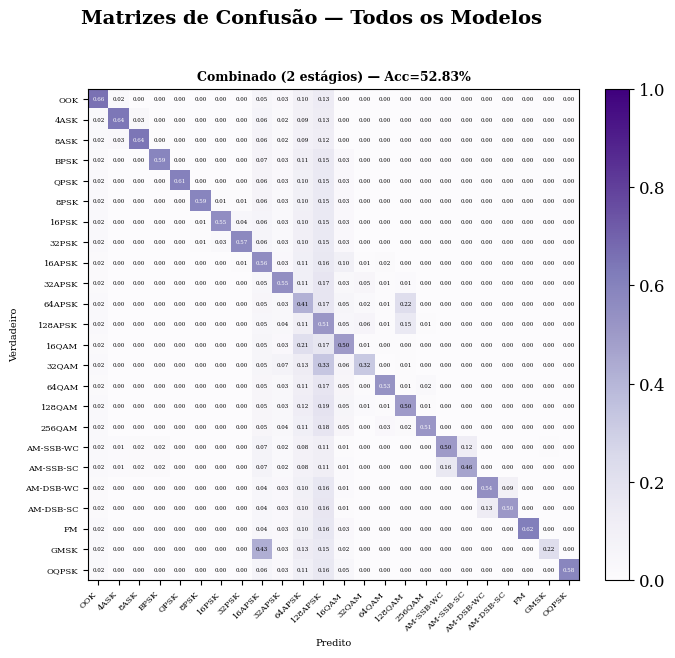

  ✅ Salvo: /content/confusion_matrices_all.png

5. Plotando acurácia × SNR


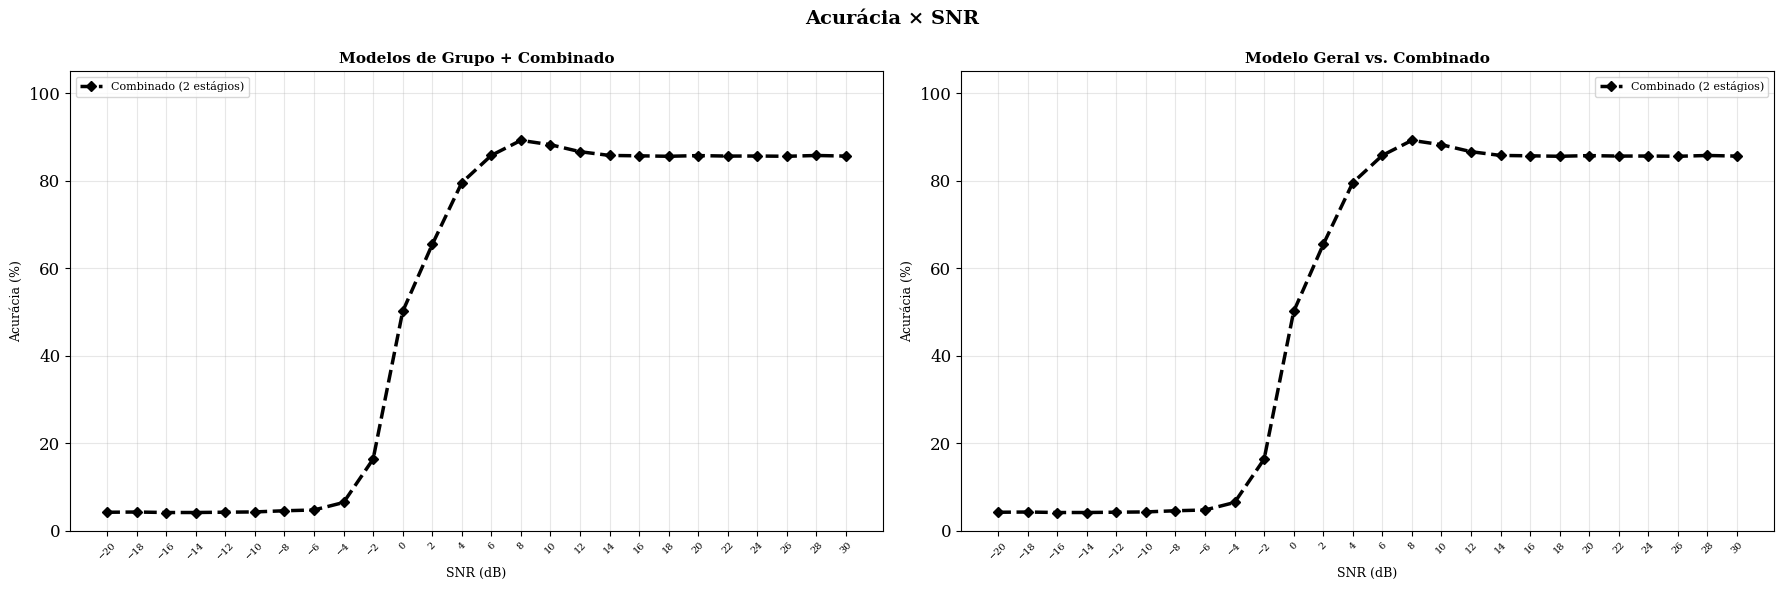

  ✅ Salvo: /content/accuracy_vs_snr_all.png


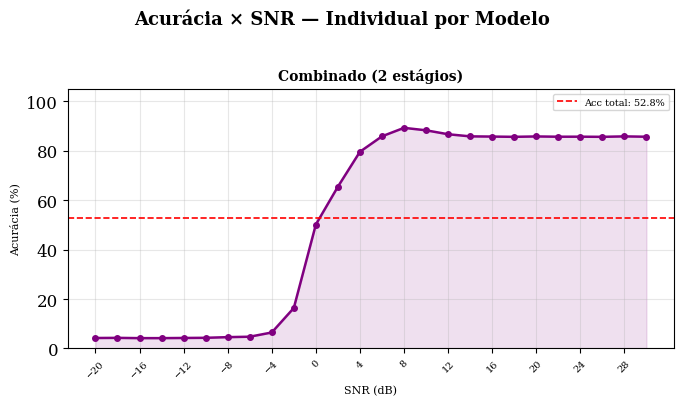

  ✅ Salvo: /content/accuracy_vs_snr_individual.png

  Modelo                               Classes   Acc Teste
─────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────
  Combinado (2 estágios)                    24      52.83%


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# AVALIAÇÃO COMPLETA
# ══════════════════════════════════════════════════════════════════════════════

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ALL_SNRS    = list(range(-20, 32, 2))
BATCH_SIZE  = 256

# ── Paths HDF5 ────────────────────────────────────────────────────────────────

def _workdir():
    for d in ['/kaggle/working', '/content', '/tmp', '/root']:
        if os.path.exists(d) and os.access(d, os.W_OK):
            return d

snr_tag_group = '_'.join(str(s) for s in [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,30])
snr_tag_geral = '_'.join(str(s) for s in ALL_SNRS)

H5_GROUP = {
    g: os.path.join(_workdir(), f'{g}_subset_snr_{snr_tag_group}.hdf5')
    for g in GROUP_NAMES.values()
}
H5_GERAL = os.path.join(_workdir(), f'subset_snr_{snr_tag_geral}.hdf5')

# ══════════════════════════════════════════════════════════════════════════════
# UTILITÁRIOS
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def predict_batch(model, x_np):
    """x_np: (N,1024,2) numpy → (N,) predições."""
    x = torch.from_numpy(x_np).float().permute(0, 2, 1).to(DEVICE)
    return model(x).argmax(dim=1).cpu().numpy()


def predict_all(model, X, batch_size=BATCH_SIZE):
    """Prediz em batches sobre um array numpy completo."""
    preds = []
    for s in range(0, len(X), batch_size):
        preds.append(predict_batch(model, X[s:s+batch_size]))
    return np.concatenate(preds)


def plot_cm(cm, class_names, title, ax, cmap='Blues'):
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    im   = ax.imshow(cm_n, vmin=0, vmax=1, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xlabel('Predito',    fontsize=7)
    ax.set_ylabel('Verdadeiro', fontsize=7)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=6)
    ax.set_yticks(ticks)
    ax.set_yticklabels(class_names, fontsize=6)
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            v = cm_n[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=4, color='white' if v > .5 else 'black')
    return im


def plot_snr_curve(snr_accs, label, ax, color, marker='o',
                   linestyle='-', lw=1.8, ms=4):
    snrs = sorted([s for s, a in snr_accs.items() if a is not None])
    vals = [snr_accs[s] for s in snrs]
    ax.plot(snrs, vals, marker=marker, markersize=ms,
            linewidth=lw, linestyle=linestyle,
            label=label, color=color)
    return snrs, vals


# ══════════════════════════════════════════════════════════════════════════════
# 1. AVALIAÇÃO DOS MODELOS DE GRUPO
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("1. Avaliando modelos de grupo")
print("=" * 60)

results_grupo = {}

for gname, model in models_grupo.items():
    h5 = H5_GROUP[gname]
    if not os.path.exists(h5):
        print(f"  ⚠️  HDF5 não encontrado para {gname}: {h5}")
        continue

    with h5py.File(h5, 'r') as f:
        X_all = f['X'][:]
        Y_all = np.argmax(f['Y'][:], axis=1)
        Z_all = f['Z'][:, 0]

    class_names = CLASSES_PER_GROUP[gname]

    # Conjunto de teste
    _, _, test_idx = split(np.arange(len(Y_all)), Y_all)
    X_test = X_all[test_idx]
    y_test = Y_all[test_idx]

    y_pred   = predict_all(model, X_test)
    test_acc = 100.0 * (y_pred == y_test).mean()
    cm       = confusion_matrix(y_test, y_pred)

    # Acurácia por SNR
    snr_accs = {}
    for snr in ALL_SNRS:
        mask = Z_all == snr
        if mask.sum() == 0:
            snr_accs[snr] = None
            continue
        yp = predict_all(model, X_all[mask])
        snr_accs[snr] = 100.0 * (yp == Y_all[mask]).mean()

    results_grupo[gname] = dict(
        cm=cm, snr_accs=snr_accs,
        test_acc=test_acc, class_names=class_names
    )
    print(f"  ✅ {gname:<6}  Acc = {test_acc:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# 2. AVALIAÇÃO DO MODELO GERAL
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("2. Avaliando modelo geral")
print("=" * 60)

result_geral = None

if os.path.exists(H5_GERAL):
    with h5py.File(H5_GERAL, 'r') as f:
        X_g = f['X'][:]
        Y_g = np.argmax(f['Y_grouped'][:], axis=1)
        Z_g = f['Z'][:, 0]

    _, _, test_idx_g = split(np.arange(len(Y_g)), Y_g)
    X_test_g = X_g[test_idx_g]
    y_test_g = Y_g[test_idx_g]

    y_pred_g   = predict_all(model_geral, X_test_g)
    test_acc_g = 100.0 * (y_pred_g == y_test_g).mean()
    cm_g       = confusion_matrix(y_test_g, y_pred_g)

    snr_accs_g = {}
    for snr in ALL_SNRS:
        mask = Z_g == snr
        if mask.sum() == 0:
            snr_accs_g[snr] = None
            continue
        yp = predict_all(model_geral, X_g[mask])
        snr_accs_g[snr] = 100.0 * (yp == Y_g[mask]).mean()

    result_geral = dict(
        cm=cm_g, snr_accs=snr_accs_g,
        test_acc=test_acc_g,
        class_names=list(GROUP_NAMES.values())
    )
    print(f"  ✅ Geral (6 grupos)  Acc = {test_acc_g:.2f}%")
else:
    print(f"  ⚠️  HDF5 geral não encontrado: {H5_GERAL}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. PREDIÇÃO COMBINADA (2 estágios)
#    Estágio 1 → modelo geral prediz grupo
#    Estágio 2 → modelo do grupo prediz modulação
#    FM (1 classe) → resposta determinística, sem modelo de grupo
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("3. Predição combinada (2 estágios)")
print("=" * 60)

# Mapas de conversão local → global por grupo
local_to_global = {}
for gname, mods in CLASSES_PER_GROUP.items():
    local_to_global[gname] = {
        local: modulation_classes.index(mod)
        for local, mod in enumerate(mods)
    }

all_mod_names = modulation_classes   # 24 classes na ordem global

y_true_comb   = []
y_pred_comb   = []
snr_accs_comb = {}

h5_original = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'

with h5py.File(h5_original, 'r') as f:
    Z_orig = f['Z'][:, 0]
    Y_orig = np.argmax(f['Y'][:], axis=1)   # 0-23

    for snr in ALL_SNRS:
        mask = Z_orig == snr
        if mask.sum() == 0:
            snr_accs_comb[snr] = None
            continue

        idx        = np.where(mask)[0]
        y_true_snr = Y_orig[idx]
        y_pred_snr = np.full(len(idx), -1, dtype=np.int64)

        # Processa em batches
        for s in range(0, len(idx), BATCH_SIZE):
            e   = min(s + BATCH_SIZE, len(idx))
            xb  = f['X'][idx[s:e]]                          # (B,1024,2)

            # ── Estágio 1: prediz grupo ───────────────────────────────────────
            grp_pred = predict_batch(model_geral, xb)        # 0-5

            # ── Estágio 2: prediz modulação dentro do grupo ───────────────────
            for grp_id in np.unique(grp_pred):
                gname    = GROUP_NAMES[grp_id]
                sub_mask = grp_pred == grp_id
                x_sub    = xb[sub_mask]

                if gname in SINGLE_CLASS_GROUPS:
                    # FM: 1 classe → índice global direto, sem modelo
                    global_idx = local_to_global[gname][0]
                    global_pred_sub = np.full(sub_mask.sum(), global_idx,
                                             dtype=np.int64)

                elif gname in models_grupo:
                    local_pred      = predict_batch(models_grupo[gname], x_sub)
                    global_pred_sub = np.array([
                        local_to_global[gname].get(lp, -1)
                        for lp in local_pred
                    ], dtype=np.int64)

                else:
                    # Grupo sem modelo → marca como -1
                    global_pred_sub = np.full(sub_mask.sum(), -1,
                                             dtype=np.int64)

                batch_positions           = np.where(sub_mask)[0] + s
                y_pred_snr[batch_positions] = global_pred_sub

        valid = y_pred_snr != -1
        if valid.sum() > 0:
            snr_accs_comb[snr] = 100.0 * (
                y_pred_snr[valid] == y_true_snr[valid]
            ).mean()
        else:
            snr_accs_comb[snr] = None

        y_true_comb.append(y_true_snr)
        y_pred_comb.append(y_pred_snr)

        acc_str = f"{snr_accs_comb[snr]:.2f}%" if snr_accs_comb[snr] else "N/A"
        print(f"  SNR {snr:>4} dB  →  Acc = {acc_str}")

y_true_comb = np.concatenate(y_true_comb)
y_pred_comb = np.concatenate(y_pred_comb)

valid_mask    = y_pred_comb != -1
y_true_comb   = y_true_comb[valid_mask]
y_pred_comb   = y_pred_comb[valid_mask]
test_acc_comb = 100.0 * (y_true_comb == y_pred_comb).mean()
cm_comb       = confusion_matrix(y_true_comb, y_pred_comb,
                                  labels=list(range(len(all_mod_names))))

print(f"\n  ✅ Combinado  Acc = {test_acc_comb:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# 4. FIGURA 1 — MATRIZES DE CONFUSÃO
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("4. Plotando matrizes de confusão")
print("=" * 60)

# Ordem: grupos → geral → combinado
plots_cm = []
for gname, res in results_grupo.items():
    plots_cm.append((
        res['cm'], res['class_names'],
        f'{gname} — Acc={res["test_acc"]:.2f}%',
        'Blues'
    ))
if result_geral:
    plots_cm.append((
        result_geral['cm'], result_geral['class_names'],
        f'Geral (6 grupos) — Acc={result_geral["test_acc"]:.2f}%',
        'Greens'
    ))
plots_cm.append((
    cm_comb, all_mod_names,
    f'Combinado (2 estágios) — Acc={test_acc_comb:.2f}%',
    'Purples'
))

ncols    = min(3, len(plots_cm))
nrows    = int(np.ceil(len(plots_cm) / ncols))
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(7.5 * ncols, 7 * nrows))
axes_flat = np.array(axes).flatten() if len(plots_cm) > 1 else [axes]

for ai, (cm_, cnames, title, cmap) in enumerate(plots_cm):
    im = plot_cm(cm_, cnames, title, axes_flat[ai], cmap=cmap)
    fig.colorbar(im, ax=axes_flat[ai], fraction=0.046, pad=0.04)

for i in range(len(plots_cm), len(axes_flat)):
    axes_flat[i].set_visible(False)

fig.suptitle('Matrizes de Confusão — Todos os Modelos',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Salvo: /content/confusion_matrices_all.png")

# ══════════════════════════════════════════════════════════════════════════════
# 5. FIGURA 2 — ACURÁCIA × SNR (painel duplo)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("5. Plotando acurácia × SNR")
print("=" * 60)

colors_grupo = plt.cm.tab10(np.linspace(0, 0.7, len(results_grupo)))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Painel esquerdo: grupos + combinado ──────────────────────────────────────
ax = axes[0]
for ci, (gname, res) in enumerate(results_grupo.items()):
    plot_snr_curve(res['snr_accs'], gname, ax,
                   color=colors_grupo[ci])

plot_snr_curve(snr_accs_comb, 'Combinado (2 estágios)', ax,
               color='black', marker='D', linestyle='--', lw=2.5, ms=5)

ax.set_title('Modelos de Grupo + Combinado', fontsize=11, fontweight='bold')
ax.set_xlabel('SNR (dB)', fontsize=9)
ax.set_ylabel('Acurácia (%)', fontsize=9)
ax.set_ylim(0, 105)
ax.set_xticks(ALL_SNRS)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)

# ── Painel direito: geral + combinado ───────────────────────────────────────
ax = axes[1]
if result_geral:
    plot_snr_curve(result_geral['snr_accs'], 'Geral (6 grupos)',
                   ax, color='royalblue', marker='s', lw=2)

plot_snr_curve(snr_accs_comb, 'Combinado (2 estágios)',
               ax, color='black', marker='D', linestyle='--', lw=2.5, ms=5)

ax.set_title('Modelo Geral vs. Combinado', fontsize=11, fontweight='bold')
ax.set_xlabel('SNR (dB)', fontsize=9)
ax.set_ylabel('Acurácia (%)', fontsize=9)
ax.set_ylim(0, 105)
ax.set_xticks(ALL_SNRS)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle('Acurácia × SNR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/accuracy_vs_snr_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Salvo: /content/accuracy_vs_snr_all.png")

# ══════════════════════════════════════════════════════════════════════════════
# 6. FIGURA 3 — ACURÁCIA × SNR INDIVIDUAL
# ══════════════════════════════════════════════════════════════════════════════

all_curves = {}
for gname, res in results_grupo.items():
    all_curves[f'Grupo {gname}'] = (res['snr_accs'], res['test_acc'], 'steelblue')
if result_geral:
    all_curves['Geral (6 grupos)'] = (
        result_geral['snr_accs'], result_geral['test_acc'], 'darkorange'
    )
all_curves['Combinado (2 estágios)'] = (snr_accs_comb, test_acc_comb, 'purple')

nc2   = min(3, len(all_curves))
nr2   = int(np.ceil(len(all_curves) / nc2))
fig2, axs2 = plt.subplots(nr2, nc2, figsize=(7 * nc2, 4 * nr2))
axs2_flat  = np.array(axs2).flatten() if len(all_curves) > 1 else [axs2]

for ai, (label, (accs, tot_acc, color)) in enumerate(all_curves.items()):
    ax   = axs2_flat[ai]
    snrs = sorted([s for s, a in accs.items() if a is not None])
    vals = [accs[s] for s in snrs]
    ax.plot(snrs, vals, marker='o', markersize=4,
            linewidth=1.8, color=color)
    ax.fill_between(snrs, vals, alpha=0.12, color=color)
    ax.axhline(tot_acc, color='red', linestyle='--', linewidth=1.2,
               label=f'Acc total: {tot_acc:.1f}%')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('SNR (dB)', fontsize=8)
    ax.set_ylabel('Acurácia (%)', fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_xticks(ALL_SNRS[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for i in range(len(all_curves), len(axs2_flat)):
    axs2_flat[i].set_visible(False)

fig2.suptitle('Acurácia × SNR — Individual por Modelo',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/accuracy_vs_snr_individual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Salvo: /content/accuracy_vs_snr_individual.png")

# ══════════════════════════════════════════════════════════════════════════════
# 7. TABELA RESUMO
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print(f"  {'Modelo':<35} {'Classes':>8}  {'Acc Teste':>10}")
print(f"{'─'*65}")
for gname, res in results_grupo.items():
    nc_ = len(res['class_names'])
    print(f"  {'Grupo ' + gname:<35} {nc_:>8}  {res['test_acc']:>9.2f}%")
if result_geral:
    print(f"  {'Geral (6 grupos)':<35} {'6':>8}  {result_geral['test_acc']:>9.2f}%")
print(f"  {'─'*62}")
print(f"  {'Combinado (2 estágios)':<35} {'24':>8}  {test_acc_comb:>9.2f}%")
print(f"{'='*65}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# AVALIAÇÃO — usa dataset original (como módulo 2, seção 3)
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py
from sklearn.metrics import confusion_matrix

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ALL_SNRS   = list(range(-20, 32, 2))
BATCH_SIZE = 256

h5_original = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'

# ── Utilitários (inalterados) ─────────────────────────────────────────────────

@torch.no_grad()
def predict_batch(model, x_np):
    x = torch.from_numpy(x_np).float().permute(0, 2, 1).to(DEVICE)
    return model(x).argmax(dim=1).cpu().numpy()

def predict_all(model, X):
    preds = []
    for s in range(0, len(X), BATCH_SIZE):
        preds.append(predict_batch(model, X[s:s+BATCH_SIZE]))
    return np.concatenate(preds)

def plot_cm_ax(cm, class_names, title, ax, cmap='Blues'):
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    im   = ax.imshow(cm_n, vmin=0, vmax=1, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Predito',    fontsize=8)
    ax.set_ylabel('Verdadeiro', fontsize=8)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=7)
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            v = cm_n[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=5, color='white' if v > .5 else 'black')
    return im

def plot_snr_ax(snr_accs, test_acc, title, ax, color):
    snrs = sorted([s for s, a in snr_accs.items() if a is not None])
    vals = [snr_accs[s] for s in snrs]
    ax.plot(snrs, vals, marker='o', markersize=4, linewidth=1.8, color=color)
    ax.fill_between(snrs, vals, alpha=0.12, color=color)
    ax.axhline(test_acc, color='red', linestyle='--',
               linewidth=1.2, label=f'Acc total: {test_acc:.1f}%')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('SNR (dB)', fontsize=8)
    ax.set_ylabel('Acurácia (%)', fontsize=8)
    ax.set_ylim(0, 105)
    ax.set_xticks(ALL_SNRS[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# ══════════════════════════════════════════════════════════════════════════════
# COLETA DE RESULTADOS — lê dataset original, filtra por grupo via Y
# ══════════════════════════════════════════════════════════════════════════════

plot_entries = []
cores_grupo  = plt.cm.tab10(np.linspace(0, 0.7, len(models_grupo)))

# Mapa: nome_mod → índice global
mod_to_global = {m: i for i, m in enumerate(modulation_classes)}

print("Avaliando modelos de grupo (via dataset original)...")

with h5py.File(h5_original, 'r') as f:
    Y_orig_oh = f['Y'][:]          # (N, 24) one-hot
    Z_orig    = f['Z'][:, 0]       # SNR por amostra

    Y_orig = np.argmax(Y_orig_oh, axis=1)   # índice global 0-23

    for ci, (gname, model) in enumerate(models_grupo.items()):
        class_names  = CLASSES_PER_GROUP[gname]
        # Índices globais das classes deste grupo
        global_idxs  = [mod_to_global[m] for m in class_names]
        # Máscara: amostras que pertencem a este grupo
        group_mask   = np.isin(Y_orig, global_idxs)

        if group_mask.sum() == 0:
            print(f"  ⚠️  Nenhuma amostra para {gname}")
            continue

        # Rótulos locais (0..n_classes_grupo-1)
        global_to_local = {g: l for l, g in enumerate(global_idxs)}
        Y_local = np.array([global_to_local[y] for y in Y_orig[group_mask]])
        Z_group = Z_orig[group_mask]

        # Split → pega apenas índices de teste
        _, _, test_idx = split(np.arange(group_mask.sum()), Y_local)

        # Carrega X apenas para este grupo
        X_group  = f['X'][np.where(group_mask)[0]]   # leitura seletiva
        X_test   = X_group[test_idx]
        y_test   = Y_local[test_idx]

        y_pred   = predict_all(model, X_test)
        test_acc = 100.0 * (y_pred == y_test).mean()
        cm       = confusion_matrix(y_test, y_pred)

        # Acurácia por SNR (todas as amostras do grupo)
        snr_accs = {}
        for snr in ALL_SNRS:
            mask = Z_group == snr
            if mask.sum() == 0:
                snr_accs[snr] = None
                continue
            yp = predict_all(model, X_group[mask])
            snr_accs[snr] = 100.0 * (yp == Y_local[mask]).mean()

        plot_entries.append((
            f'Grupo {gname}  (Acc={test_acc:.2f}%)',
            cm, class_names, snr_accs, test_acc,
            'Blues', cores_grupo[ci]
        ))
        print(f"  ✅ {gname:<6}  Acc = {test_acc:.2f}%")

# ── Modelo geral ──────────────────────────────────────────────────────────────

print("\nAvaliando modelo geral (via dataset original)...")

with h5py.File(h5_original, 'r') as f:
    # Y_grouped: índice de grupo (0-5) por amostra
    Y_grp  = np.argmax(f['Y_grouped'][:], axis=1) if 'Y_grouped' in f \
             else np.array([                              # deriva se não existir
                 next(gi for gi, mods in CLASSES_PER_GROUP.items()
                      if modulation_classes[y] in CLASSES_PER_GROUP[gi])
                 for y in Y_orig
             ])
    Z_orig = f['Z'][:, 0]

    _, _, test_idx_g = split(np.arange(len(Y_grp)), Y_grp)
    X_test_g = f['X'][test_idx_g]
    y_test_g = Y_grp[test_idx_g]

    y_pred_g   = predict_all(model_geral, X_test_g)
    test_acc_g = 100.0 * (y_pred_g == y_test_g).mean()
    cm_g       = confusion_matrix(y_test_g, y_pred_g)

    snr_accs_g = {}
    for snr in ALL_SNRS:
        mask = Z_orig == snr
        if mask.sum() == 0:
            snr_accs_g[snr] = None
            continue
        yp = predict_all(model_geral, f['X'][mask])
        snr_accs_g[snr] = 100.0 * (yp == Y_grp[mask]).mean()

plot_entries.append((
    f'Geral — 6 Grupos  (Acc={test_acc_g:.2f}%)',
    cm_g, list(GROUP_NAMES.values()),
    snr_accs_g, test_acc_g,
    'Greens', 'darkorange'
))
print(f"  ✅ Geral  Acc = {test_acc_g:.2f}%")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA
# ══════════════════════════════════════════════════════════════════════════════

if not plot_entries:
    print("\n❌ Nenhum modelo avaliado. Verifique os modelos carregados.")
else:
    n_models = len(plot_entries)
    fig, axes = plt.subplots(
        n_models, 2,
        figsize=(16, 6.5 * n_models),
        gridspec_kw={'width_ratios': [1, 1.4]}
    )
    if n_models == 1:
        axes = np.array([axes])

    for row, (title, cm, cnames, snr_accs, test_acc, cmap, color) in enumerate(plot_entries):
        im = plot_cm_ax(cm, cnames, f'Matriz de Confusão\n{title}', axes[row,0], cmap=cmap)
        fig.colorbar(im, ax=axes[row,0], fraction=0.046, pad=0.04)
        plot_snr_ax(snr_accs, test_acc, f'Acurácia × SNR\n{title}', axes[row,1], color=color)

    fig.suptitle('Avaliação por Modelo — Matriz de Confusão + Acurácia × SNR',
                 fontsize=14, fontweight='bold', y=1.005)
    plt.tight_layout()
    out = path + '/avaliacao_por_modelo.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Salvo: {out}")

    print(f"\n{'='*55}")
    print(f"  {'Modelo':<30} {'Classes':>8}  {'Acc Teste':>10}")
    print(f"{'─'*55}")
    for (title, _, cnames, _, test_acc, _, _) in plot_entries:
        label = title.split('(')[0].strip()
        print(f"  {label:<30} {len(cnames):>8}  {test_acc:>9.2f}%")
    print(f"{'='*55}")

NameError: name 'path' is not defined

Carregando metadados (Y, Z)...

──────────────────────────────────────────────────
Avaliando grupo: ASK
  Acc teste = 76.04%
  ✅ ASK concluído

──────────────────────────────────────────────────
Avaliando grupo: PSK
  Acc teste = 67.26%
  ✅ PSK concluído

──────────────────────────────────────────────────
Avaliando grupo: APSK
  Acc teste = 69.25%
  ✅ APSK concluído

──────────────────────────────────────────────────
Avaliando grupo: QAM
  Acc teste = 62.32%
  ✅ QAM concluído

──────────────────────────────────────────────────
Avaliando grupo: AM
  Acc teste = 60.26%
  ✅ AM concluído

──────────────────────────────────────────────────
Avaliando modelo geral...
  Acc teste = 61.82%
  ✅ Geral concluído


OSError: [Errno 30] Read-only file system: '/kaggle/input/radioml2018/avaliacao_por_modelo.png'

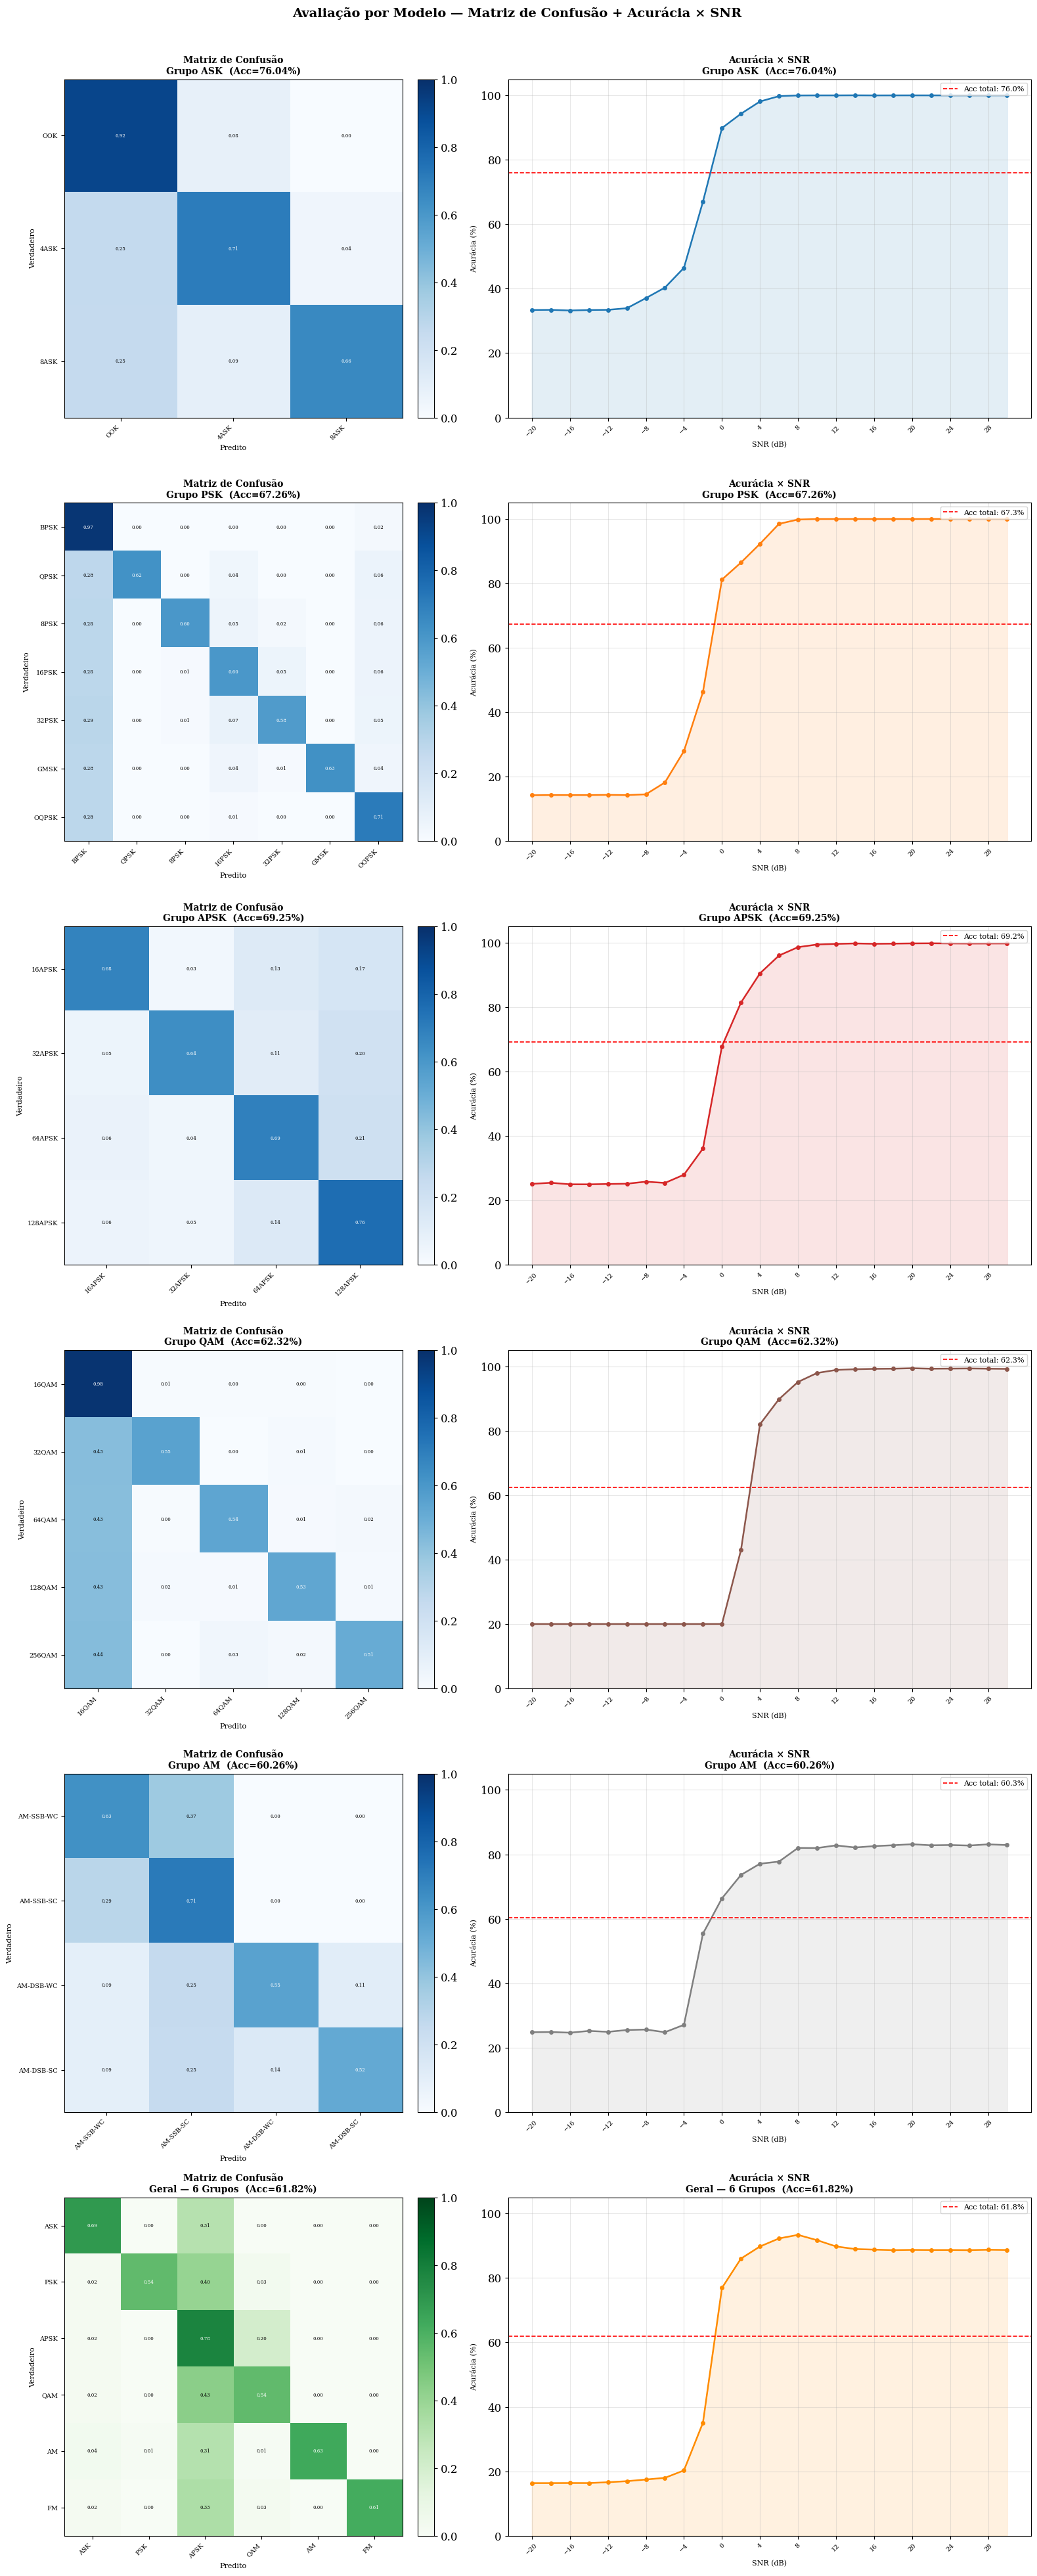

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# AVALIAÇÃO — streaming por batch, RAM mínima
# ══════════════════════════════════════════════════════════════════════════════

import numpy as np
import torch
import matplotlib.pyplot as plt
import h5py
from sklearn.metrics import confusion_matrix

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ALL_SNRS   = list(range(-20, 32, 2))
BATCH_SIZE = 256

h5_original = path + '/GOLD_XYZ_OSC.0001_1024.hdf5'

# ── Utilitários ───────────────────────────────────────────────────────────────

@torch.no_grad()
def predict_batch(model, x_np):
    x = torch.from_numpy(x_np).float().permute(0, 2, 1).to(DEVICE)
    return model(x).argmax(dim=1).cpu().numpy()

def plot_cm_ax(cm, class_names, title, ax, cmap='Blues'):
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
    im   = ax.imshow(cm_n, vmin=0, vmax=1, cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('Predito', fontsize=8)
    ax.set_ylabel('Verdadeiro', fontsize=8)
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=7)
    for i in range(cm_n.shape[0]):
        for j in range(cm_n.shape[1]):
            v = cm_n[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=5, color='white' if v > .5 else 'black')
    return im

def plot_snr_ax(snr_accs, test_acc, title, ax, color):
    snrs = sorted([s for s, a in snr_accs.items() if a is not None])
    vals = [snr_accs[s] for s in snrs]
    ax.plot(snrs, vals, marker='o', markersize=4, linewidth=1.8, color=color)
    ax.fill_between(snrs, vals, alpha=0.12, color=color)
    ax.axhline(test_acc, color='red', linestyle='--',
               linewidth=1.2, label=f'Acc total: {test_acc:.1f}%')
    ax.set_title(title, fontsize=10, fontweight='bold', pad=6)
    ax.set_xlabel('SNR (dB)', fontsize=8); ax.set_ylabel('Acurácia (%)', fontsize=8)
    ax.set_ylim(0, 105); ax.set_xticks(ALL_SNRS[::2])
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Lê metadados uma única vez (Y e Z são pequenos) ──────────────────────────

print("Carregando metadados (Y, Z)...")
with h5py.File(h5_original, 'r') as f:
    Y_orig = np.argmax(f['Y'][:], axis=1)   # índice global 0-23  (~few MB)
    Z_orig = f['Z'][:, 0]                   # SNR por amostra      (~few MB)
    N_total = len(Y_orig)
    # Y_grouped se existir
    Y_grp = np.argmax(f['Y_grouped'][:], axis=1) if 'Y_grouped' in f else None

mod_to_global   = {m: i for i, m in enumerate(modulation_classes)}
cores_grupo     = plt.cm.tab10(np.linspace(0, 0.7, len(models_grupo)))
plot_entries    = []

# ══════════════════════════════════════════════════════════════════════════════
# MODELOS DE GRUPO — um por vez, streaming do HDF5
# ══════════════════════════════════════════════════════════════════════════════

for ci, (gname, model) in enumerate(models_grupo.items()):
    print(f"\n{'─'*50}")
    print(f"Avaliando grupo: {gname}")

    class_names = CLASSES_PER_GROUP[gname]
    global_idxs = [mod_to_global[m] for m in class_names]
    global_to_local = {g: l for l, g in enumerate(global_idxs)}

    # Índices das amostras deste grupo (só índices, sem carregar X)
    group_idx = np.where(np.isin(Y_orig, global_idxs))[0]
    Y_local   = np.array([global_to_local[Y_orig[i]] for i in group_idx])
    Z_group   = Z_orig[group_idx]

    if len(group_idx) == 0:
        print(f"  ⚠️  Nenhuma amostra encontrada para {gname}")
        continue

    # Split → índices de teste dentro de group_idx
    _, _, test_rel = split(np.arange(len(group_idx)), Y_local)
    test_abs       = group_idx[test_rel]   # posições absolutas no HDF5
    y_test         = Y_local[test_rel]

    # ── Avaliação no conjunto de teste — batch streaming ─────────────────────
    y_pred_test = []
    with h5py.File(h5_original, 'r') as f:
        for s in range(0, len(test_abs), BATCH_SIZE):
            idx_b = test_abs[s:s + BATCH_SIZE]
            # h5py aceita índices fancy apenas se ordenados
            order  = np.argsort(idx_b)
            idx_s  = idx_b[order]
            xb     = f['X'][idx_s]          # lê só este batch do disco
            # restaura ordem original
            xb     = xb[np.argsort(order)]
            y_pred_test.append(predict_batch(model, xb))
            del xb

    y_pred_test = np.concatenate(y_pred_test)
    test_acc    = 100.0 * (y_pred_test == y_test).mean()
    cm          = confusion_matrix(y_test, y_pred_test)
    del y_pred_test
    print(f"  Acc teste = {test_acc:.2f}%")

    # ── Acurácia por SNR — batch streaming ───────────────────────────────────
    snr_accs = {}
    with h5py.File(h5_original, 'r') as f:
        for snr in ALL_SNRS:
            snr_mask  = Z_group == snr
            snr_abs   = group_idx[snr_mask]
            y_snr     = Y_local[snr_mask]

            if len(snr_abs) == 0:
                snr_accs[snr] = None
                continue

            preds = []
            for s in range(0, len(snr_abs), BATCH_SIZE):
                idx_b  = snr_abs[s:s + BATCH_SIZE]
                order  = np.argsort(idx_b)
                xb     = f['X'][idx_b[order]][np.argsort(order)]
                preds.append(predict_batch(model, xb))
                del xb

            preds = np.concatenate(preds)
            snr_accs[snr] = 100.0 * (preds == y_snr).mean()
            del preds

    plot_entries.append((
        f'Grupo {gname}  (Acc={test_acc:.2f}%)',
        cm, class_names, snr_accs, test_acc,
        'Blues', cores_grupo[ci]
    ))
    print(f"  ✅ {gname} concluído")

    # Libera modelo da GPU após uso
    model.cpu()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

# ══════════════════════════════════════════════════════════════════════════════
# MODELO GERAL — streaming
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*50}")
print("Avaliando modelo geral...")

if Y_grp is None:
    # Deriva Y_grp a partir do mapa de grupos
    grp_map = {}
    for gi, (gname, mods) in enumerate(CLASSES_PER_GROUP.items()):
        for m in mods:
            grp_map[mod_to_global[m]] = gi
    Y_grp = np.array([grp_map.get(y, -1) for y in Y_orig])

_, _, test_idx_g = split(np.arange(N_total), Y_grp)
y_test_g         = Y_grp[test_idx_g]
test_abs_g       = np.array(test_idx_g)

model_geral.to(DEVICE)
y_pred_g = []
with h5py.File(h5_original, 'r') as f:
    for s in range(0, len(test_abs_g), BATCH_SIZE):
        idx_b  = test_abs_g[s:s + BATCH_SIZE]
        order  = np.argsort(idx_b)
        xb     = f['X'][idx_b[order]][np.argsort(order)]
        y_pred_g.append(predict_batch(model_geral, xb))
        del xb

y_pred_g   = np.concatenate(y_pred_g)
test_acc_g = 100.0 * (y_pred_g == y_test_g).mean()
cm_g       = confusion_matrix(y_test_g, y_pred_g)
del y_pred_g
print(f"  Acc teste = {test_acc_g:.2f}%")

snr_accs_g = {}
with h5py.File(h5_original, 'r') as f:
    for snr in ALL_SNRS:
        mask   = Z_orig == snr
        abs_idx = np.where(mask)[0]
        y_snr  = Y_grp[mask]
        if len(abs_idx) == 0:
            snr_accs_g[snr] = None
            continue
        preds = []
        for s in range(0, len(abs_idx), BATCH_SIZE):
            idx_b = abs_idx[s:s + BATCH_SIZE]
            order = np.argsort(idx_b)
            xb    = f['X'][idx_b[order]][np.argsort(order)]
            preds.append(predict_batch(model_geral, xb))
            del xb
        preds = np.concatenate(preds)
        snr_accs_g[snr] = 100.0 * (preds == y_snr).mean()
        del preds

model_geral.cpu()
torch.cuda.empty_cache() if torch.cuda.is_available() else None

plot_entries.append((
    f'Geral — 6 Grupos  (Acc={test_acc_g:.2f}%)',
    cm_g, list(GROUP_NAMES.values()),
    snr_accs_g, test_acc_g,
    'Greens', 'darkorange'
))
print("  ✅ Geral concluído")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA
# ══════════════════════════════════════════════════════════════════════════════

if not plot_entries:
    print("\n❌ Nenhum modelo avaliado.")
else:
    n_models = len(plot_entries)
    fig, axes = plt.subplots(
        n_models, 2,
        figsize=(16, 6.5 * n_models),
        gridspec_kw={'width_ratios': [1, 1.4]}
    )
    if n_models == 1:
        axes = np.array([axes])

    for row, (title, cm, cnames, snr_accs, test_acc, cmap, color) in enumerate(plot_entries):
        im = plot_cm_ax(cm, cnames, f'Matriz de Confusão\n{title}', axes[row, 0], cmap=cmap)
        fig.colorbar(im, ax=axes[row, 0], fraction=0.046, pad=0.04)
        plot_snr_ax(snr_accs, test_acc, f'Acurácia × SNR\n{title}', axes[row, 1], color=color)

    fig.suptitle('Avaliação por Modelo — Matriz de Confusão + Acurácia × SNR',
                 fontsize=14, fontweight='bold', y=1.005)
    plt.tight_layout()
    out = path + '/avaliacao_por_modelo.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n✅ Salvo: {out}")

    print(f"\n{'='*55}")
    print(f"  {'Modelo':<30} {'Classes':>8}  {'Acc Teste':>10}")
    print(f"{'─'*55}")
    for (title, _, cnames, _, test_acc, _, _) in plot_entries:
        print(f"  {title.split('(')[0].strip():<30} {len(cnames):>8}  {test_acc:>9.2f}%")
    print(f"{'='*55}")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO GERAL — baixíssimo consumo de RAM
# ══════════════════════════════════════════════════════════════════════════════

print(f"\n{'─'*50}")
print("Avaliando modelo geral...")

# Y_grp já calculado anteriormente; Z_orig também
# ── Amostragem estratificada leve ────────────────────────────────────────────
# Em vez de usar split() no dataset inteiro, pega até MAX_PER_CLASS
# amostras de teste por grupo → RAM controlada

MAX_PER_CLASS = 2000   # ajuste para cima se houver RAM sobrando

rng = np.random.default_rng(42)
test_abs_g_list = []
y_test_g_list   = []

for grp_id in np.unique(Y_grp):
    idx_grp = np.where(Y_grp == grp_id)[0]
    n_pick  = min(MAX_PER_CLASS, len(idx_grp))
    chosen  = rng.choice(idx_grp, size=n_pick, replace=False)
    test_abs_g_list.append(chosen)
    y_test_g_list.append(np.full(n_pick, grp_id))

test_abs_g = np.concatenate(test_abs_g_list)
y_test_g   = np.concatenate(y_test_g_list)

# Ordena para leitura sequencial no HDF5 (muito mais rápido)
order      = np.argsort(test_abs_g)
test_abs_g = test_abs_g[order]
y_test_g   = y_test_g[order]

del test_abs_g_list, y_test_g_list, order

print(f"  Amostras de teste: {len(test_abs_g):,}  "
      f"({MAX_PER_CLASS} por grupo × {len(np.unique(Y_grp))} grupos)")

# ── Predição no teste — batch streaming ──────────────────────────────────────
model_geral.to(DEVICE)
correct = 0
total   = 0
y_pred_g_all = []   # só para a CM — integers, custo baixo

with h5py.File(h5_original, 'r') as f:
    for s in range(0, len(test_abs_g), BATCH_SIZE):
        idx_b  = test_abs_g[s:s + BATCH_SIZE]
        xb     = f['X'][idx_b]              # sequencial → sem reordenação
        yb     = y_test_g[s:s + BATCH_SIZE]
        preds  = predict_batch(model_geral, xb)
        correct += (preds == yb).sum()
        total   += len(yb)
        y_pred_g_all.append(preds)
        del xb, preds

test_acc_g = 100.0 * correct / total
y_pred_g   = np.concatenate(y_pred_g_all)
del y_pred_g_all
cm_g = confusion_matrix(y_test_g, y_pred_g,
                        labels=list(range(len(GROUP_NAMES))))
del y_pred_g
print(f"  Acc teste = {test_acc_g:.2f}%")

# ── Acurácia por SNR — um SNR por vez, sem acumular ──────────────────────────
snr_accs_g = {}
with h5py.File(h5_original, 'r') as f:
    for snr in ALL_SNRS:
        # Índices absolutos deste SNR, ordenados
        snr_abs = np.where(Z_orig == snr)[0]   # já são posições absolutas
        y_snr   = Y_grp[snr_abs]

        if len(snr_abs) == 0:
            snr_accs_g[snr] = None
            continue

        # Sub-amostra por SNR se ainda for grande
        if len(snr_abs) > MAX_PER_CLASS * len(GROUP_NAMES):
            chosen  = rng.choice(len(snr_abs),
                                 size=MAX_PER_CLASS * len(GROUP_NAMES),
                                 replace=False)
            chosen.sort()
            snr_abs = snr_abs[chosen]
            y_snr   = y_snr[chosen]
            del chosen

        correct_snr = 0
        total_snr   = 0
        for s in range(0, len(snr_abs), BATCH_SIZE):
            idx_b = snr_abs[s:s + BATCH_SIZE]
            xb    = f['X'][idx_b]
            yb    = y_snr[s:s + BATCH_SIZE]
            preds = predict_batch(model_geral, xb)
            correct_snr += (preds == yb).sum()
            total_snr   += len(yb)
            del xb, preds

        snr_accs_g[snr] = 100.0 * correct_snr / total_snr
        del snr_abs, y_snr
        print(f"    SNR {snr:>4} dB → {snr_accs_g[snr]:.2f}%")

model_geral.cpu()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

plot_entries.append((
    f'Geral — 6 Grupos  (Acc={test_acc_g:.2f}%)',
    cm_g, list(GROUP_NAMES.values()),
    snr_accs_g, test_acc_g,
    'Greens', 'darkorange'
))
print("  ✅ Geral concluído")


──────────────────────────────────────────────────
Avaliando modelo geral...
  Amostras de teste: 1  (2000 por grupo × 1 grupos)


/tmp/ipykernel_39570/1930621600.py:20: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  idx_grp = np.where(Y_grp == grp_id)[0]


ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [ ]:

model_geral = load_model("/content/cnn_GROUP_ep001_acc88.61_lr1.00e-03.pth", num_classes=6)


models_grupo = {}
for gname in GROUP_NAMES.values():
    nc    = len(CLASSES_PER_GROUP[gname])
    ckpt  = find_checkpoint(MODEL_BASE_DIR, f'cnn_{gname}') \
         or find_checkpoint('/content',      f'cnn_{gname}')
    if ckpt is None:
        print(f"  ⚠️  {gname}: checkpoint não encontrado — grupo será ignorado")
        continue
    models_grupo[gname] = load_model(ckpt, num_classes=nc)
    print(f"  ✓ {gname:<6}       : {os.path.basename(ckpt)}")


Tamanho detectado para o Flatten: 31744
Tamanho detectado para o Flatten: 31744
  ✓ ASK          : cnn_ASK_ep001_acc97.99_lr1.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✓ PSK          : cnn_PSK_ep007_acc95.93_lr5.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✓ APSK         : cnn_APSK_ep007_acc92.47_lr1.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✓ QAM          : cnn_QAM_ep014_acc84.15_lr5.00e-06.pth
Tamanho detectado para o Flatten: 31744
  ✓ AM           : cnn_AM_ep006_acc80.08_lr5.00e-06.pth
  ⚠️  FM: checkpoint não encontrado — grupo será ignorado


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CÉLULA PARA GARANTIR GERAÇÃO DE TODOS OS HDF5 NECESSÁRIOS PARA O PLOT
# ══════════════════════════════════════════════════════════════════════════════

import os, json, shutil, random
import h5py
import numpy as np
import torch
from sklearn.model_selection import train_test_split

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURAÇÕES (replicadas da célula de treinamento unificada p39SJmZ61vh7)
# ══════════════════════════════════════════════════════════════════════════════

# Certifique-se de que `path` e `modulation_classes_path` estejam definidos
# de células anteriores (e.g., `wLOx9RJwg8HZ`).
# Se não estiverem, descomente e ajuste as linhas abaixo:
# import kagglehub
# path = kagglehub.dataset_download("pinxau1000/radioml2018")
# modulation_classes_path = path + '/classes-fixed.json'

# Desired SNRs for all generated HDF5 files
DESIRED_SNRS = list(range(-20, 32, 2)) # All SNRs from -20 to 30 dB

BATCH_SIZE_IO = 2048 # Batch size for HDF5 I/O operations
LOCAL_DIR    = "/content" # Directory to store generated HDF5 files locally

# ══════════════════════════════════════════════════════════════════════════════
# MAPA DE GRUPOS (igual ao resto do notebook)
# ══════════════════════════════════════════════════════════════════════════════

GROUP_MAP = {
    "OOK":       0, "4ASK":      0, "8ASK":      0,
    "BPSK":      1, "QPSK":      1, "8PSK":      1,
    "16PSK":     1, "32PSK":     1, "GMSK":      1, "OQPSK":     1,
    "16APSK":    2, "32APSK":    2, "64APSK":    2, "128APSK":   2,
    "16QAM":     3, "32QAM":     3, "64QAM":     3, "128QAM":    3, "256QAM":    3,
    "AM-SSB-WC": 4, "AM-SSB-SC": 4, "AM-DSB-WC": 4, "AM-DSB-SC": 4,
    "FM":        5,
}
GROUP_NAMES  = {0: "ASK", 1: "PSK", 2: "APSK", 3: "QAM", 4: "AM", 5: "FM"}
ALL_MODELS   = ["GROUP", "ASK", "PSK", "APSK", "QAM", "AM", "FM"]

INPUT_FILE   = path + "/GOLD_XYZ_OSC.0001_1024.hdf5"
CLASSES_FILE = modulation_classes_path

mod_classes = json.load(open(CLASSES_FILE))

# ══════════════════════════════════════════════════════════════════════════════
# FUNÇÃO DE CONSTRUÇÃO DE HDF5 (copiada da célula p39SJmZ61vh7)
# ══════════════════════════════════════════════════════════════════════════════

def _build_hdf5(input_file, output_file, target_snrs,
                group_indices, global_to_local, num_classes,
                modelo_id, batch_size=BATCH_SIZE_IO, mod_classes=mod_classes, GROUP_MAP=GROUP_MAP):
    """Filtra INPUT_FILE por SNR (e grupo se intra-grupo) e grava output_file."""
    snr_set = set(target_snrs)
    if os.path.exists(output_file):
        os.remove(output_file)

    print(f"\n  🔨 Construindo HDF5 para '{modelo_id}'...")

    original_indices = []
    with h5py.File(input_file, 'r') as src:
        N     = src['X'].shape[0]
        Z_ds  = src['Z']
        Y_ds  = src['Y']
        n_b   = int(np.ceil(N / batch_size))

        for i in range(n_b):
            s, e     = i * batch_size, min((i + 1) * batch_size, N)
            z_batch  = Z_ds[s:e, 0]
            y_batch  = np.argmax(Y_ds[s:e], axis=1)

            if modelo_id == "GROUP":
                mask = np.isin(z_batch, list(snr_set))
            else:
                mask = (np.isin(z_batch, list(snr_set)) &
                        np.isin(y_batch, group_indices))

            original_indices.extend((np.where(mask)[0] + s).tolist())
            if (i + 1) % 50 == 0 or i == n_b - 1:
                print(f"    Batch {i+1:>4}/{n_b}  |  amostras: {len(original_indices)}")

    original_indices = np.array(original_indices, dtype=np.int64)
    M = len(original_indices)
    if M == 0:
        print(f"  ⚠️  Nenhuma amostra encontrada para '{modelo_id}' com os filtros escolhidos.")
        return None

    NUM_GROUPS = 6
    lookup = np.array([GROUP_MAP[mod_classes[i]]
                       for i in range(len(mod_classes))], dtype=np.int64)

    with h5py.File(input_file, 'r') as src:
        x_shape = src['X'].shape[1:]
        z_shape = src['Z'].shape[1:]

        with h5py.File(output_file, 'w') as out:
            # Metadados para reconstrução futura
            out.attrs['snrs']          = target_snrs
            out.attrs['modelo_id']     = modelo_id
            out.attrs['num_classes']   = num_classes
            out.attrs['group_indices'] = group_indices.tolist()
            out.attrs['total_samples'] = M
            out.attrs['seed']          = 42 # Using a fixed seed for reproducibility

            ds_X  = out.create_dataset('X', shape=(M,)+x_shape, dtype=src['X'].dtype)
            ds_Z  = out.create_dataset('Z', shape=(M,)+z_shape, dtype=src['Z'].dtype)

            if modelo_id == "GROUP":
                # Y_grouped: one-hot de 6 grupos
                ds_Y = out.create_dataset('Y_grouped',
                                          shape=(M, NUM_GROUPS), dtype=np.float32)
            else:
                # Y: one-hot local (num_classes do grupo)
                ds_Y = out.create_dataset('Y',
                                          shape=(M, num_classes), dtype=np.int32)

            n_b = int(np.ceil(M / batch_size))
            for i in range(n_b):
                s, e = i * batch_size, min((i + 1) * batch_size, M)
                idx  = original_indices[s:e]

                ds_X[s:e] = src['X'][idx]
                ds_Z[s:e] = src['Z'][idx]

                y_global = np.argmax(src['Y'][idx], axis=1)

                if modelo_id == "GROUP":
                    y_group = lookup[y_global]
                    yg = np.zeros((e - s, NUM_GROUPS), dtype=np.float32)
                    yg[np.arange(e - s), y_group] = 1.0
                    ds_Y[s:e] = yg
                else:
                    y_local = np.array([global_to_local[int(g)] for g in y_global])
                    yo = np.zeros((e - s, num_classes), dtype=np.int32)
                    yo[np.arange(e - s), y_local] = 1
                    ds_Y[s:e] = yo

                if (i + 1) % 20 == 0 or i == n_b - 1:
                    print(f"    Escrevendo batch {i+1:>4}/{n_b}")

    print(f"  ✅ HDF5 criado: {output_file}  ({M} amostras)")
    return output_file

# ══════════════════════════════════════════════════════════════════════════════
# GERAR HDF5 PARA TODOS OS MODELOS
# ══════════════════════════════════════════════════════════════════════════════

snr_tag_for_files = '_'.join(str(s) for s in DESIRED_SNRS)

for MODELO_ALVO in ALL_MODELS:
    print(f"\n{'='*70}")
    print(f"Processando MODELO_ALVO: {MODELO_ALVO}")
    print(f"{'='*70}")

    if MODELO_ALVO == "GROUP":
        group_indices   = np.arange(len(mod_classes), dtype=np.int64)
        num_classes     = 6
        global_to_local = {int(g): GROUP_MAP[mod_classes[g]] for g in group_indices}
        h5_name   = f'{'_'.join(sorted(GROUP_NAMES.values()))}_subset_snr_{snr_tag_for_files}.hdf5'
    else:
        group_indices = np.array(
            sorted([i for i, m in enumerate(mod_classes)
                    if GROUP_NAMES[GROUP_MAP[m]] == MODELO_ALVO]),
            dtype=np.int64
        )
        num_classes     = len(group_indices)
        global_to_local = {int(g): l for l, g in enumerate(group_indices)}
        h5_name   = f'{MODELO_ALVO}_subset_snr_{snr_tag_for_files}.hdf5'

    output_file_path = os.path.join(LOCAL_DIR, h5_name)

    _build_hdf5(INPUT_FILE, output_file_path, DESIRED_SNRS,
                group_indices, global_to_local, num_classes,
                MODELO_ALVO, batch_size=BATCH_SIZE_IO)

print("\n✅ Todos os arquivos HDF5 necessários foram gerados.")
print("Agora você pode executar a célula de plotagem novamente.")


Processando MODELO_ALVO: GROUP

  🔨 Construindo HDF5 para 'GROUP'...
    Batch   50/1248  |  amostras: 102400
    Batch  100/1248  |  amostras: 204800
    Batch  150/1248  |  amostras: 307200
    Batch  200/1248  |  amostras: 409600
    Batch  250/1248  |  amostras: 512000
    Batch  300/1248  |  amostras: 614400
    Batch  350/1248  |  amostras: 716800
    Batch  400/1248  |  amostras: 819200
    Batch  450/1248  |  amostras: 921600
    Batch  500/1248  |  amostras: 1024000
    Batch  550/1248  |  amostras: 1126400
    Batch  600/1248  |  amostras: 1228800
    Batch  650/1248  |  amostras: 1331200
    Batch  700/1248  |  amostras: 1433600
    Batch  750/1248  |  amostras: 1536000
    Batch  800/1248  |  amostras: 1638400
    Batch  850/1248  |  amostras: 1740800
    Batch  900/1248  |  amostras: 1843200
    Batch  950/1248  |  amostras: 1945600
    Batch 1000/1248  |  amostras: 2048000
    Batch 1050/1248  |  amostras: 2150400
    Batch 1100/1248  |  amostras: 2252800
    Batch 1150/